# Kelp Canopy EDA — KelpWatch Landsat Time Series

Exploratory data analysis of the SBC LTER / KelpWatch Landsat-derived kelp canopy dataset for the **California kelp coast (Monterey → Mendocino, 36.5–40.0°N)**, 2002–present. Full time series extends to 1984; the analysis window matches the Copernicus Marine notebook to enable future joint analysis.

| Section | Content |
|---|---|
| 0 | Data quality — temporal coverage, sensor transitions, SLC failure period |
| 1 | Kelp canopy area time series + year × quarter heatmap |
| 2 | Spatial decomposition — latitude bands as species proxy |
| 3 | Anomaly analysis (2002–2012 pre-collapse baseline) |
| 4 | Pre vs post-collapse composites |
| 5 | Trend analysis — OLS, Mann-Whitney, post-collapse OLS (Monterey), biomass vs canopy area |
| 6 | Summary of findings |

> **Species note:** The dataset contains one `area` variable (total kelp canopy area — both *Macrocystis pyrifera* and *Nereocystis luetkeana*) and one `biomass` variable (giant kelp only). Separate Nereocystis variables are not present. Latitude-band decomposition serves as a species proxy: Mendocino pixels (38.5–40°N) are predominantly bull kelp; Monterey pixels (36.5–37.8°N) are predominantly giant kelp.

## Data Source

| Dataset | Citation | Variables | Grain | Coverage | Period | Res. |
|---|---|---|---|---|---|---|
| SBC LTER Landsat Kelp | Bell, Cavanaugh, Siegel / knb-lter-sbc.74.29 | `area` (m²/pixel, all kelp), `biomass` (kg wet wt/pixel, giant kelp only), `passes` (obs count per sensor) | Quarterly | Monterey–Mendocino coast | 1984–2025 Q2 | 30 m |

**Data access:** Environmental Data Initiative (EDI) PASTA API — public, no login required. Single ~2.4 GB NetCDF file covering the full West Coast (585,408 coastal pixels × 166 quarters). The ETL cell downloads and caches this file, then saves a domain subset (~45 k coastal pixels) for fast reuse.

**Sensor timeline:**

| Sensor | Period | Variable | Notes |
|---|---|---|---|
| Landsat 4/5 TM | 1984–2013 | `passes5` | 16-day repeat |
| Landsat 7 ETM+ | 1999–present | `passes7` | SLC failure **May 2003** — ~22% data loss per image thereafter |
| Landsat 8/9 OLI | 2013–present | `passes8` | Highest SNR; 8-day repeat when combined with L7 |
| Landsat 6 | never | `passes6` | Failed at launch; always 0 |

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as _scipy_stats
from pathlib import Path
import requests
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [2]:
# ── Geographic domain ─────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX = 36.5, 40.0      # Monterey → Mendocino
LON_MIN, LON_MAX = -125.0, -121.0  # full nearshore range
# No lon cutoff applied: KelpWatch is a classification product —
# non-kelp pixels (Sacramento Delta, SF Bay interior) are absent by construction.

# ── Latitude bands (species proxy) ───────────────────────────────────────────
LAT_BINS = [
    ('Monterey',  36.5, 37.8, '#1f78b4'),  # predominantly giant kelp (Macrocystis)
    ('Bodega/SF', 37.8, 38.5, '#33a02c'),  # mixed
    ('Mendocino', 38.5, 40.0, '#e31a1c'),  # predominantly bull kelp (Nereocystis)
]

# ── Data access ───────────────────────────────────────────────────────────────
CACHE_DIR = Path('data/kelpwatch_cache')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

NC_FILE  = CACHE_DIR / 'LandsatKelpBiomass_2025_Q2.nc'
SUB_FILE = CACHE_DIR / 'kelp_domain_subset.nc'

# EDI PASTA direct download — public, no authentication
PASTA_URL = ('https://pasta.lternet.edu/package/data/eml/'
             'knb-lter-sbc/74/29/c2bea785267fa434c40a22e2239bb337')

# ── Analysis parameters ───────────────────────────────────────────────────────
ANALYSIS_START_YR = 2002  # match Copernicus Marine notebook
BASELINE_END_YR   = 2012  # last year of pre-collapse baseline; 2013+ = post-collapse

# Quarter → phenological stage (simplified for quarterly resolution)
# Q1 (Jan-Mar) → Recruit   Q2 (Apr-Jun) → Growth
# Q3 (Jul-Sep) → Peak      Q4 (Oct-Dec) → Senescence
Q_STAGE  = {1: 'Recruit', 2: 'Growth', 3: 'Peak', 4: 'Senes.'}
Q_COLORS = {1: '#4daf4a', 2: '#984ea3', 3: '#ff7f00', 4: '#e41a1c'}

COLLAPSE_LINE = pd.Timestamp(f'{BASELINE_END_YR + 1}-01-01')  # vertical line in plots

In [3]:
# ── Helpers ───────────────────────────────────────────────────────────────────
def build_dates(ds):
    """Build DatetimeIndex (first day of each quarter) from year/quarter arrays."""
    q_month = {1: 1, 2: 4, 3: 7, 4: 10}
    return pd.to_datetime([
        f"{int(y)}-{q_month[int(q)]:02d}-01"
        for y, q in zip(ds['year'].values, ds['quarter'].values)
    ])

def quarterly_anomaly(series, baseline_end_yr=BASELINE_END_YR):
    """Quarterly series → subtract per-quarter climatology from baseline period."""
    s    = series.copy()
    base = s[s.index.year <= baseline_end_yr]
    clim = base.groupby(base.index.month).mean()  # keyed by first month of quarter
    anom = s.copy()
    for m in clim.index:
        mask = s.index.month == m
        anom.loc[mask] = s.loc[mask] - clim.loc[m]
    return anom

def ols_trend(series):
    """Return (slope, p_value) via OLS linear regression."""
    s = series.dropna()
    if len(s) < 4:
        return np.nan, np.nan
    res = _scipy_stats.linregress(np.arange(len(s)), s.values)
    return res.slope, res.pvalue

def masked_mean(ds_sub, var='area'):
    """Domain-mean of var; pixels with passes=0 treated as no-data."""
    vals   = ds_sub[var].values.copy().astype(float)
    passes = ds_sub['passes'].values
    vals[passes == 0] = np.nan
    return np.nanmean(vals, axis=1)

def total_km2(ds_sub, var='area'):
    """Total kelp canopy area in km² per timestep (sum across domain pixels)."""
    vals   = ds_sub[var].values.copy().astype(float)
    passes = ds_sub['passes'].values
    vals[passes == 0] = 0.0
    return np.nansum(vals, axis=1) / 1e6  # m² → km²

In [4]:
# ── ETL: Download → subset → cache ───────────────────────────────────────────
def download_nc(url, dest):
    if dest.exists():
        print(f'Using cached: {dest}  ({dest.stat().st_size / 1e9:.2f} GB)')
        return
    print(f'Downloading (~2.4 GB): {url}')
    r = requests.get(url, stream=True)
    total = int(r.headers.get('content-length', 0))
    with open(dest, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True) as pbar:
        for chunk in r.iter_content(1024 * 1024):
            f.write(chunk)
            pbar.update(len(chunk))

download_nc(PASTA_URL, NC_FILE)

KEEP_VARS = ['latitude', 'longitude', 'year', 'quarter',
             'area', 'biomass', 'passes', 'passes5', 'passes7', 'passes8']

# Invalidate cache if biomass wasn't included in a prior run
if SUB_FILE.exists():
    with xr.open_dataset(SUB_FILE) as _check:
        if 'biomass' not in _check.data_vars:
            print('Cached subset missing biomass — deleting and regenerating ...')
            SUB_FILE.unlink()

if SUB_FILE.exists():
    print(f'Loading cached subset: {SUB_FILE}')
    ds = xr.open_dataset(SUB_FILE)
else:
    import netCDF4 as _nc4, time as _time

    with _nc4.Dataset(NC_FILE) as _src:
        lat = _src['latitude'][:]
        lon = _src['longitude'][:]

    mask = (
        (lat >= LAT_MIN) & (lat <= LAT_MAX) &
        (lon >= LON_MIN) & (lon <= LON_MAX)
    )
    idx = np.where(mask)[0]
    n_station = len(idx)
    print(f'Domain pixels: {n_station:,} of {len(lat):,} total')

    print('Writing domain subset (one-time) ...')
    t0 = _time.time()
    with _nc4.Dataset(NC_FILE) as src, _nc4.Dataset(SUB_FILE, 'w') as dst:
        n_time = len(src.dimensions['time'])
        dst.setncatts({k: src.getncattr(k) for k in src.ncattrs()})
        dst.createDimension('time',    n_time)
        dst.createDimension('station', n_station)

        for vname in KEEP_VARS:
            v = src[vname]
            if v.dimensions == ('station',):
                dv = dst.createVariable(vname, v.dtype, v.dimensions,
                                        zlib=True, complevel=4)
                dv.setncatts({k: v.getncattr(k) for k in v.ncattrs()})
                dv[:] = np.array(v[:])[idx]

            elif v.dimensions == ('time', 'station'):
                dv = dst.createVariable(vname, v.dtype, v.dimensions,
                                        zlib=True, complevel=4,
                                        chunksizes=(1, n_station))
                dv.setncatts({k: v.getncattr(k) for k in v.ncattrs()})
                for t in range(n_time):
                    dv[t, :] = np.array(v[t, :])[idx]
                print(f'  {vname}: done  ({n_time} rows)')
                continue

            else:  # ('time',) — year, quarter
                dv = dst.createVariable(vname, v.dtype, v.dimensions,
                                        zlib=True, complevel=4)
                dv.setncatts({k: v.getncattr(k) for k in v.ncattrs()})
                dv[:] = np.array(v[:])

            print(f'  {vname}: done')

    print(f'Subset saved → {SUB_FILE}  ({SUB_FILE.stat().st_size/1e6:.0f} MB)'
          f'  [{_time.time()-t0:.0f}s]')
    ds = xr.open_dataset(SUB_FILE)

# Drop time steps with fill-value year/quarter (int16 fill = -32767)
qs_raw  = ds['quarter'].values.astype(int)
yrs_raw = ds['year'].values.astype(int)
valid_t = np.isin(qs_raw, [1, 2, 3, 4]) & (yrs_raw > 0)
if not valid_t.all():
    print(f'Dropping {(~valid_t).sum()} fill-value time step(s)')
    ds = ds.isel(time=np.where(valid_t)[0])

# Build time index and restrict to analysis window
dates = build_dates(ds)
yrs   = ds['year'].values.astype(int)
qs    = ds['quarter'].values.astype(int)

t_mask  = yrs >= ANALYSIS_START_YR
ds_a    = ds.isel(time=np.where(t_mask)[0])
dates_a = dates[t_mask]
yrs_a   = yrs[t_mask]
qs_a    = qs[t_mask]

print(f'\nFull record:     {dates[0].date()} → {dates[-1].date()}  ({len(dates)} quarters)')
print(f'Analysis window: {dates_a[0].date()} → {dates_a[-1].date()}  ({len(dates_a)} quarters)')
print(f'Stations:        {ds.sizes["station"]:,}')
print(f'Variables:       {list(ds.data_vars)}')

Using cached: data/kelpwatch_cache/LandsatKelpBiomass_2025_Q2.nc  (2.54 GB)
Loading cached subset: data/kelpwatch_cache/kelp_domain_subset.nc

Full record:     1984-01-01 → 2025-04-01  (166 quarters)
Analysis window: 2002-01-01 → 2025-04-01  (94 quarters)
Stations:        45,564
Variables:       ['latitude', 'longitude', 'year', 'quarter', 'area', 'biomass', 'passes', 'passes5', 'passes7', 'passes8']


## Section 0 — Data Quality

Temporal coverage, observation counts per sensor, and flagging of the Landsat 7 SLC failure period (May 2003 onwards).

| Check | Threshold |
|---|---|
| Mean passes per quarter | ≥ 2 observations/pixel |
| Coverage gaps | Flag quarters where > 20% of domain pixels have passes = 0 |
| Landsat 7 post-SLC drop | Expected ≥ 2003 Q2 — verify, do not correct |

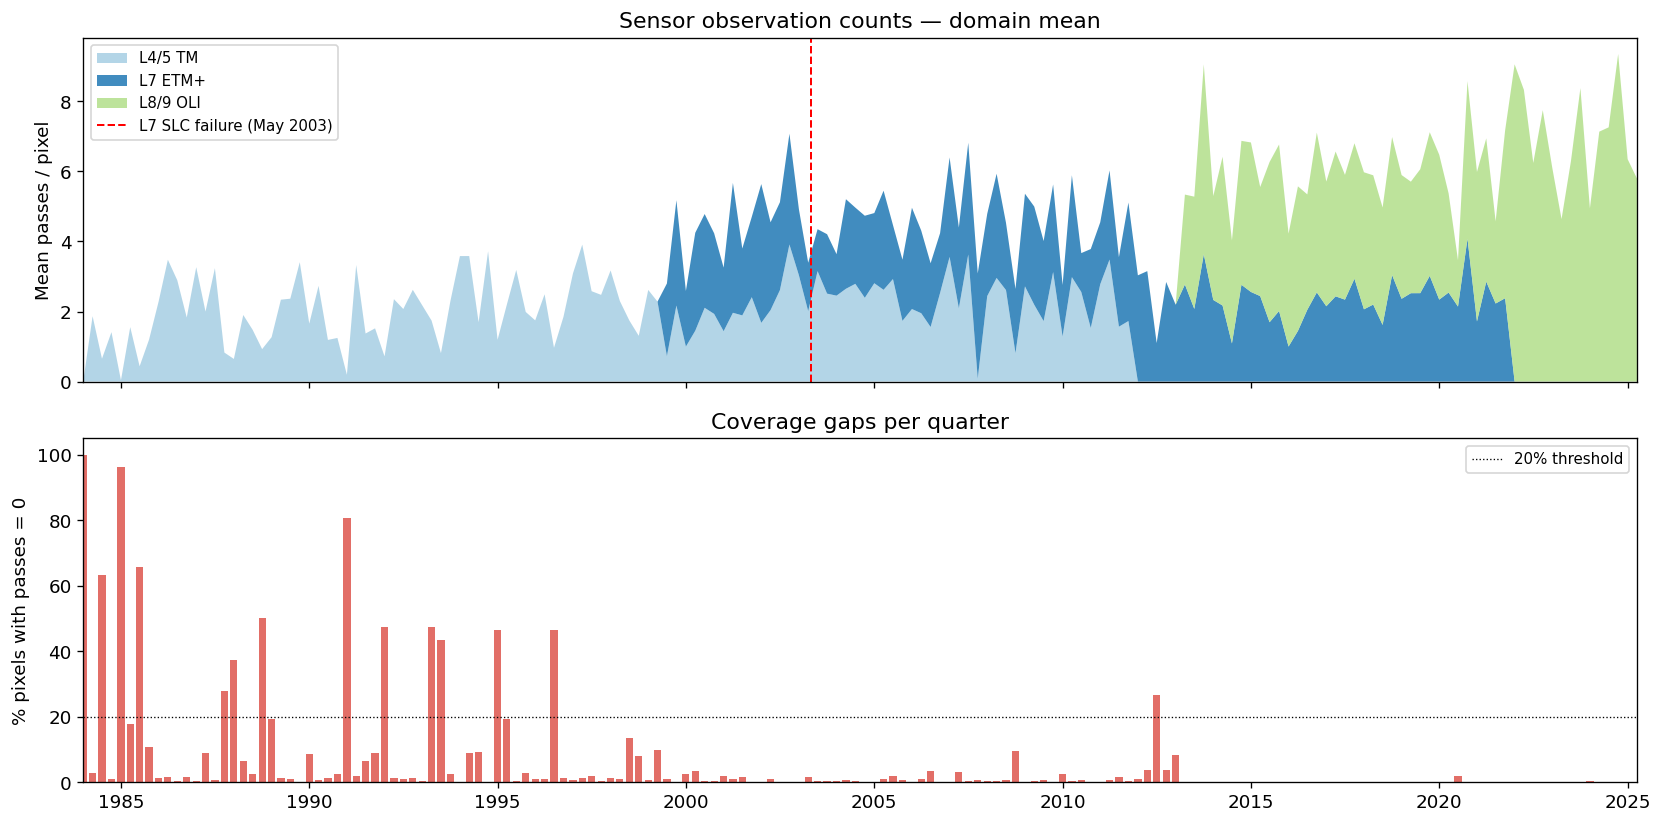

[WARN] 14 quarter(s) with >20% zero-pass pixels: [(1984, 1), (1984, 3), (1985, 1), (1985, 3), (1987, 4), (1988, 1), (1988, 4), (1991, 1), (1992, 1), (1993, 2)]
L7 passes (1999–2003 pre-SLC) = 2.47  (2003–2007 post-SLC) = 2.07  (drop = 16%)


In [5]:
# ── 0a. Sensor contribution and coverage gaps ─────────────────────────────────
mean_p5  = ds['passes5'].values.mean(axis=1)
mean_p7  = ds['passes7'].values.mean(axis=1)
mean_p8  = ds['passes8'].values.mean(axis=1)
pct_zero = (ds['passes'].values == 0).mean(axis=1) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.stackplot(dates, mean_p5, mean_p7, mean_p8,
              labels=['L4/5 TM', 'L7 ETM+', 'L8/9 OLI'],
              colors=['#a6cee3', '#1f78b4', '#b2df8a'], alpha=0.85)
ax1.axvline(pd.Timestamp('2003-05-01'), color='red', lw=1.2, ls='--',
            label='L7 SLC failure (May 2003)')
ax1.set_ylabel('Mean passes / pixel')
ax1.set_title('Sensor observation counts — domain mean')
ax1.legend(loc='upper left', fontsize=9)
ax1.set_xlim(dates[0], dates[-1])

ax2.bar(dates, pct_zero, width=70, color='#d73027', alpha=0.7)
ax2.axhline(20, color='black', lw=0.8, ls=':', label='20% threshold')
ax2.set_ylabel('% pixels with passes = 0')
ax2.set_title('Coverage gaps per quarter')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

bad_qs = [(int(yrs[i]), int(qs[i])) for i in range(len(dates)) if pct_zero[i] > 20]
if bad_qs:
    print(f'[WARN] {len(bad_qs)} quarter(s) with >20% zero-pass pixels: {bad_qs[:10]}')
else:
    print('[PASS] All quarters have ≤20% zero-pass pixels')

# Compare L7 passes in a narrow window straddling the SLC failure.
# Restricting to the L7-operational era (launch 1999 → failure 2003 → +4yr)
# avoids confounding with the pre-L7 era (passes7=0) and the L8/9 era (2013+).
l7_launch    = pd.Timestamp('1999-06-01')
slc_fail     = pd.Timestamp('2003-05-01')
slc_post_end = pd.Timestamp('2007-06-01')

slc_pre  = mean_p7[(dates >= l7_launch) & (dates < slc_fail)].mean()
slc_post = mean_p7[(dates >= slc_fail)  & (dates < slc_post_end)].mean()
drop_pct = (1 - slc_post / max(slc_pre, 1e-9)) * 100
direction = 'drop' if drop_pct > 0 else 'increase'
print(f'L7 passes (1999–2003 pre-SLC) = {slc_pre:.2f}  '
      f'(2003–2007 post-SLC) = {slc_post:.2f}  '
      f'({direction} = {abs(drop_pct):.0f}%)')

## Section 1 — Kelp Canopy Area

1. Domain-mean canopy area per pixel (m²) colored by phenological stage
2. Total domain canopy extent (km²)
3. Year × quarter heatmap

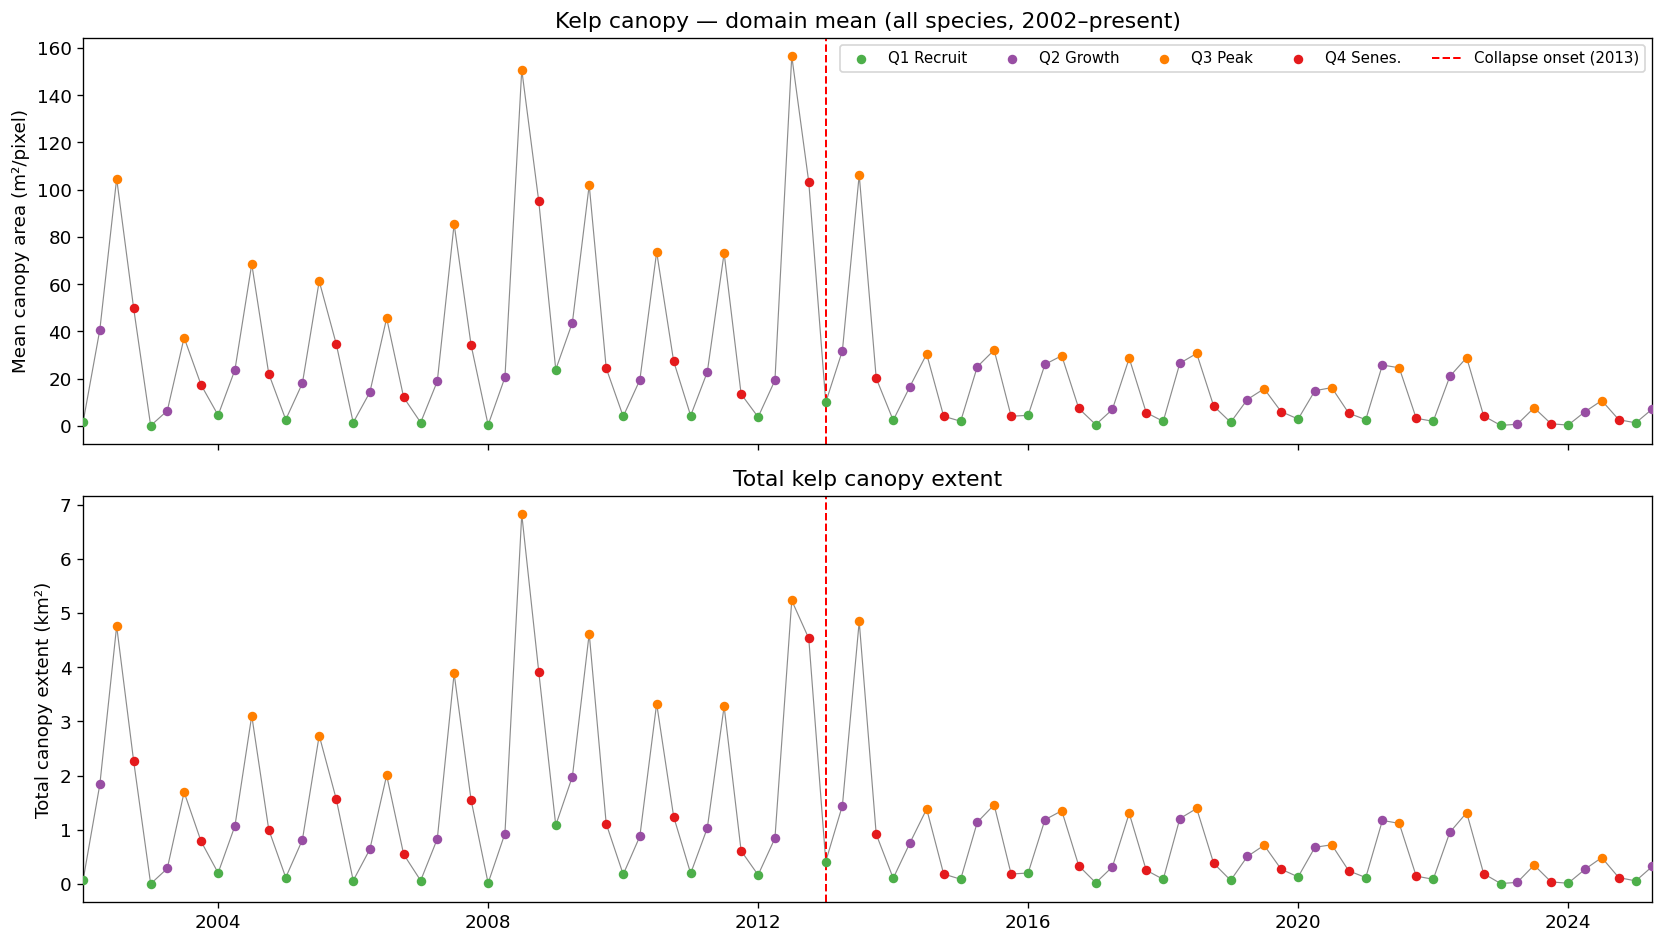

Mean area: mean=25.2  max=156.6 (2012-07-01)  min=0.1 (2003-01-01)
Extent:    range=0.00 – 6.82 km²


In [6]:
# ── 1.1 Time series ───────────────────────────────────────────────────────────
mean_area = masked_mean(ds_a)
ext_km2   = total_km2(ds_a)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for q in range(1, 5):
    m = qs_a == q
    ax1.scatter(dates_a[m], mean_area[m], color=Q_COLORS[q], s=22,
                label=f'Q{q} {Q_STAGE[q]}', zorder=3)
    ax2.scatter(dates_a[m], ext_km2[m], color=Q_COLORS[q], s=22, zorder=3)

ax1.plot(dates_a, mean_area, color='0.55', lw=0.7, zorder=1)
ax2.plot(dates_a, ext_km2,   color='0.55', lw=0.7, zorder=1)

for ax in (ax1, ax2):
    ax.axvline(COLLAPSE_LINE, color='red', lw=1.2, ls='--', label='Collapse onset (2013)')
    ax.set_xlim(dates_a[0], dates_a[-1])

ax1.set_ylabel('Mean canopy area (m²/pixel)')
ax1.set_title('Kelp canopy — domain mean (all species, 2002–present)')
ax1.legend(ncol=5, fontsize=9)

ax2.set_ylabel('Total canopy extent (km²)')
ax2.set_title('Total kelp canopy extent')

plt.tight_layout()
plt.show()

print(f'Mean area: mean={mean_area.mean():.1f}  '
      f'max={mean_area.max():.1f} ({dates_a[mean_area.argmax()].date()})  '
      f'min={mean_area.min():.1f} ({dates_a[mean_area.argmin()].date()})')
print(f'Extent:    range={ext_km2.min():.2f} – {ext_km2.max():.2f} km²')

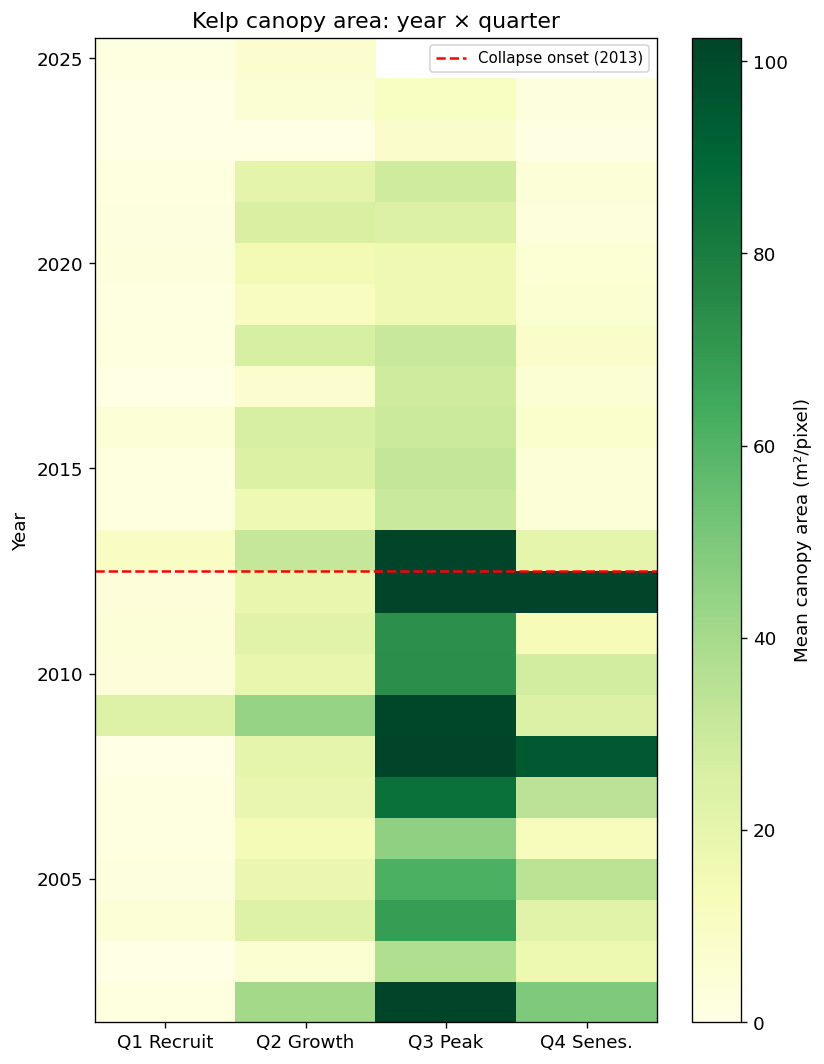

In [7]:
# ── 1.2 Year × quarter heatmap ───────────────────────────────────────────────
ana_yrs   = np.unique(yrs_a)
hm_area   = np.full((len(ana_yrs), 4), np.nan)
for i, (y, q) in enumerate(zip(yrs_a, qs_a)):
    hm_area[np.searchsorted(ana_yrs, y), q - 1] = mean_area[i]

fig, ax = plt.subplots(figsize=(7, 9))
vmax = np.nanpercentile(hm_area, 95)
im = ax.pcolor(np.arange(1, 5), ana_yrs, hm_area, cmap='YlGn', vmin=0, vmax=vmax)
ax.axhline(BASELINE_END_YR + 0.5, color='red', lw=1.5, ls='--', label='Collapse onset (2013)')
plt.colorbar(im, ax=ax, label='Mean canopy area (m²/pixel)')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['Q1 Recruit', 'Q2 Growth', 'Q3 Peak', 'Q4 Senes.'])
ax.set_ylabel('Year')
ax.set_title('Kelp canopy area: year × quarter')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Section 2 — Spatial Decomposition

Latitude-binned canopy area time series. Because *Macrocystis* and *Nereocystis* have distinct geographic ranges, lat bins serve as a species proxy:

| Bin | Lat range | Pixels | Dominant species |
|---|---|---|---|
| Monterey | 36.5–37.8°N | ~15,707 | Giant kelp (*Macrocystis pyrifera*) |
| Bodega/SF | 37.8–38.5°N | ~1,696 | Mixed |
| Mendocino | 38.5–40.0°N | ~28,161 | Bull kelp (*Nereocystis luetkeana*) |

Monterey: 15,707 px  |  mean = 49.1 m²/px
Bodega/SF: 1,696 px  |  mean = 13.4 m²/px
Mendocino: 28,161 px  |  mean = 12.6 m²/px


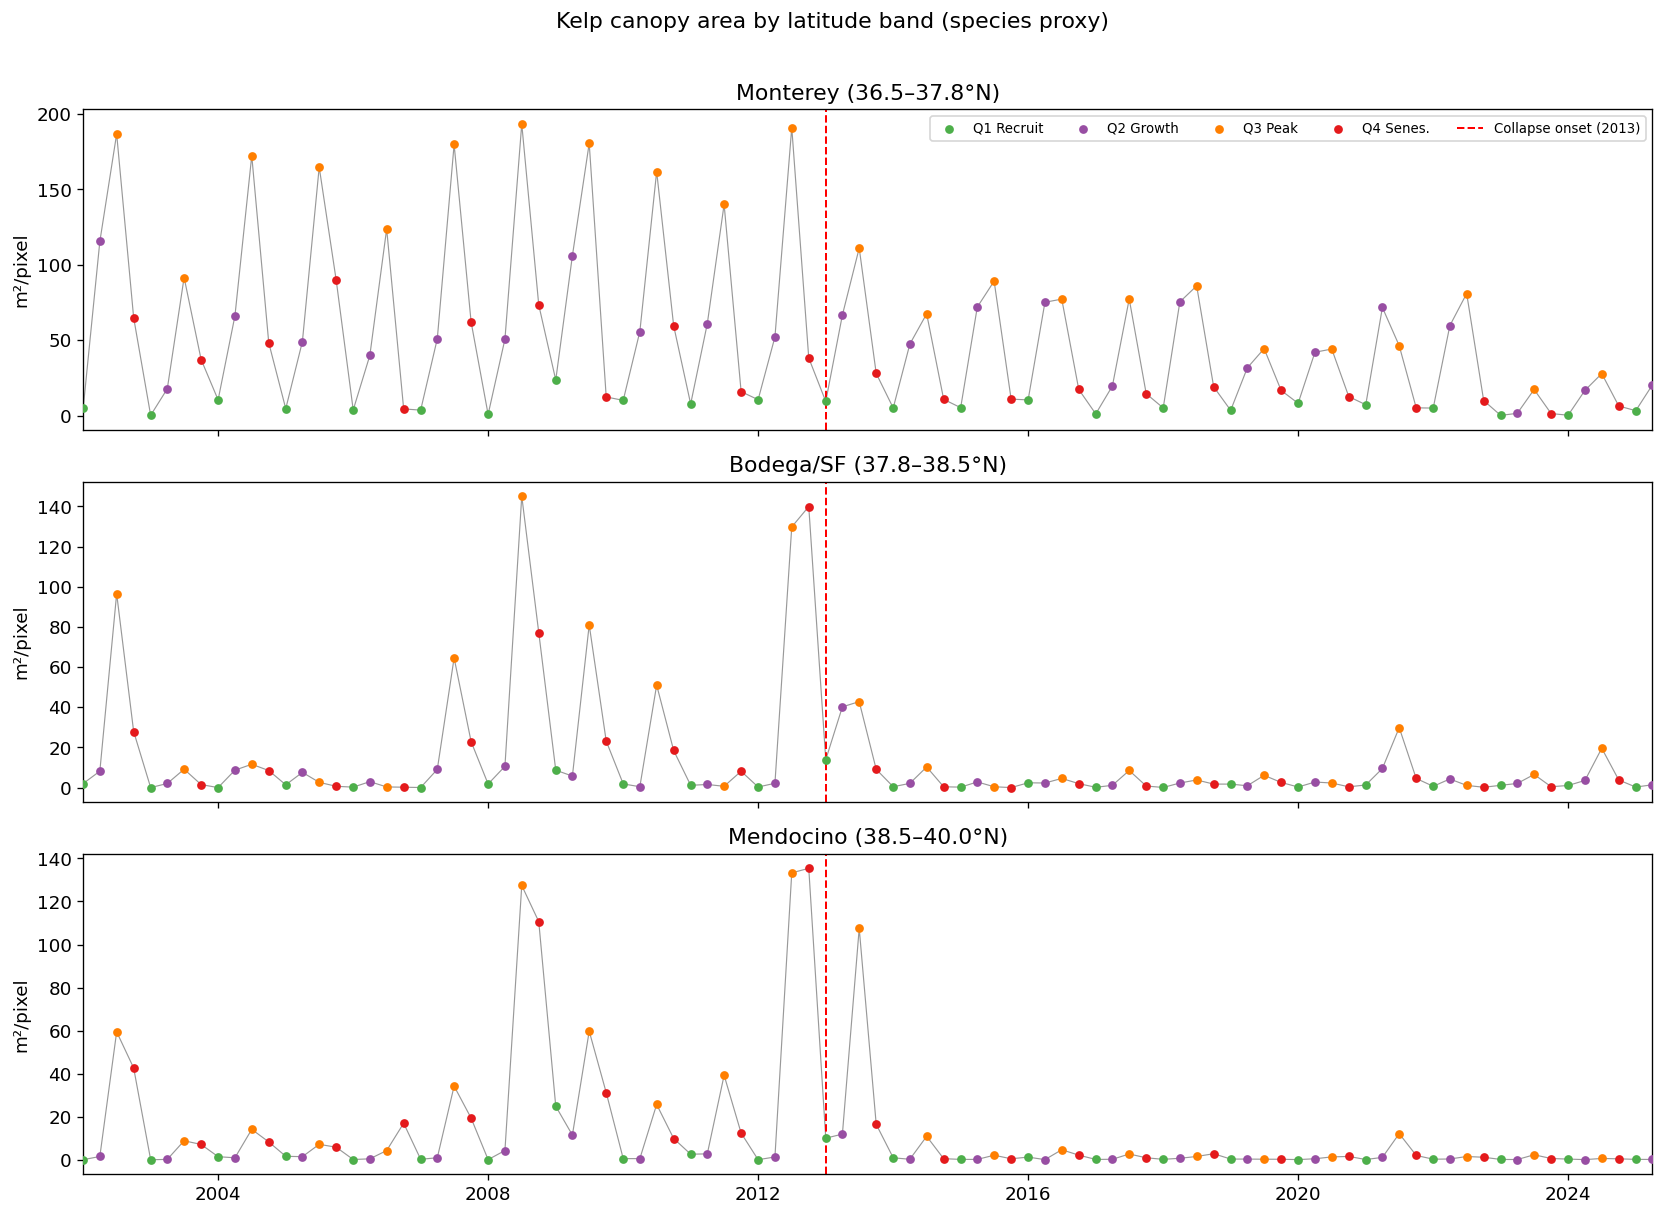

In [8]:
# ── 2.1 Lat-band time series ──────────────────────────────────────────────────
lat_px = ds_a['latitude'].values
bin_series = {}

for label, la, lb, _ in LAT_BINS:
    idx = np.where((lat_px >= la) & (lat_px < lb))[0]
    if len(idx) == 0:
        print(f'[WARN] No pixels in {label} bin')
        continue
    ds_bin = ds_a.isel(station=idx)
    vals   = ds_bin['area'].values.copy().astype(float)
    vals[ds_bin['passes'].values == 0] = np.nan
    bin_series[label] = np.nanmean(vals, axis=1)
    print(f'{label}: {len(idx):,} px  |  mean = {np.nanmean(bin_series[label]):.1f} m²/px')

fig, axes = plt.subplots(len(bin_series), 1, figsize=(14, 10), sharex=True)

for ax, (label, la, lb, color) in zip(axes, LAT_BINS):
    if label not in bin_series:
        continue
    series = bin_series[label]
    for q in range(1, 5):
        m = qs_a == q
        ax.scatter(dates_a[m], series[m], color=Q_COLORS[q], s=18, zorder=3,
                   label=f'Q{q} {Q_STAGE[q]}')
    ax.plot(dates_a, series, color='0.6', lw=0.7, zorder=1)
    ax.axvline(COLLAPSE_LINE, color='red', lw=1.2, ls='--', label='Collapse onset (2013)')
    ax.set_ylabel('m²/pixel')
    ax.set_title(f'{label} ({la}–{lb}°N)')
    ax.set_xlim(dates_a[0], dates_a[-1])

axes[0].legend(ncol=5, fontsize=8)
plt.suptitle('Kelp canopy area by latitude band (species proxy)', y=1.01)
plt.tight_layout()
plt.show()

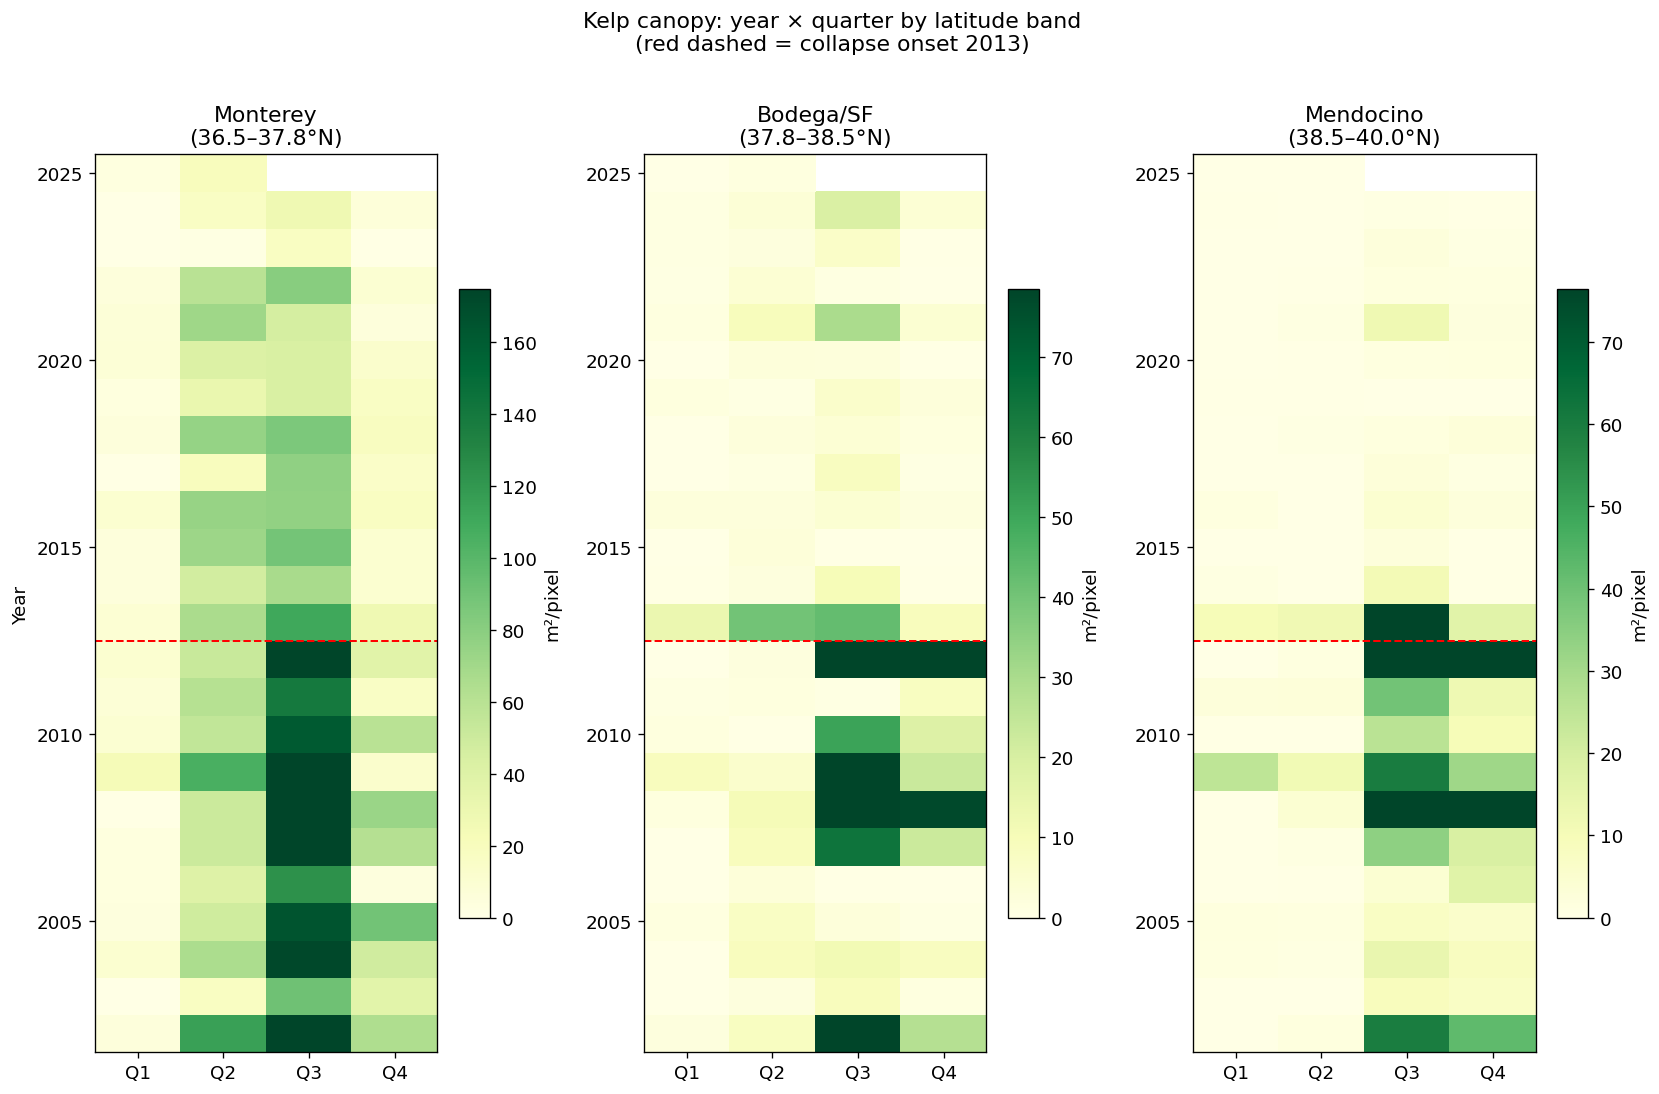

In [9]:
# ── 2.2 Lat-band year × quarter heatmaps ─────────────────────────────────────
fig, axes = plt.subplots(1, len(bin_series), figsize=(14, 9))

for ax, (label, la, lb, _) in zip(axes, LAT_BINS):
    if label not in bin_series:
        ax.axis('off')
        continue
    series = bin_series[label]
    hm = np.full((len(ana_yrs), 4), np.nan)
    for i, (y, q) in enumerate(zip(yrs_a, qs_a)):
        hm[np.searchsorted(ana_yrs, y), q - 1] = series[i]
    vmax = np.nanpercentile(hm, 95)
    im = ax.pcolor(np.arange(1, 5), ana_yrs, hm, cmap='YlGn', vmin=0, vmax=vmax)
    ax.axhline(BASELINE_END_YR + 0.5, color='red', lw=1.2, ls='--')
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
    ax.set_title(f'{label}\n({la}–{lb}°N)')
    plt.colorbar(im, ax=ax, label='m²/pixel', shrink=0.7)

axes[0].set_ylabel('Year')
plt.suptitle('Kelp canopy: year × quarter by latitude band\n(red dashed = collapse onset 2013)', y=1.01)
plt.tight_layout()
plt.show()

## Section 3 — Anomaly Analysis

Quarterly anomalies from a **2002–2012 pre-collapse baseline** — same reference period as the Copernicus Marine notebook. Per-quarter climatology (Q1–Q4) computed from all quarters in 2002–2012, then subtracted from the full analysis record.

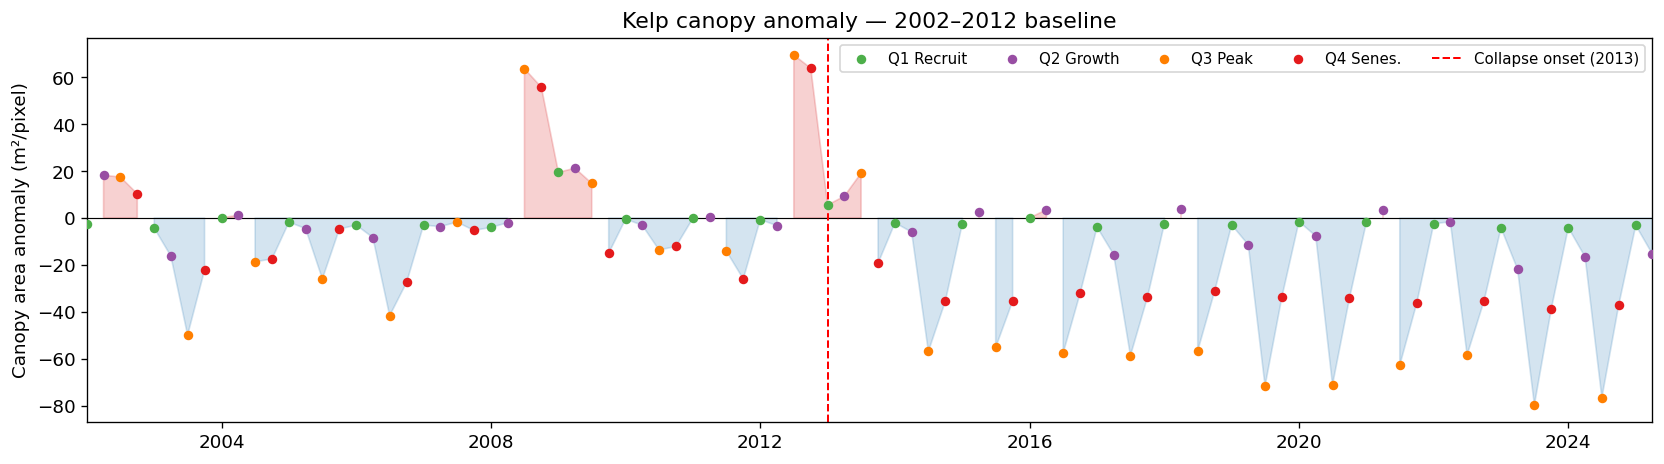

Max positive anomaly: 69.40 m²/pixel  @ 2012-07-01
Max negative anomaly: -79.54 m²/pixel  @ 2023-07-01


In [10]:
# ── 3.1 Domain-mean anomaly time series ──────────────────────────────────────
s_area = pd.Series(mean_area, index=dates_a)
anom   = quarterly_anomaly(s_area)

fig, ax = plt.subplots(figsize=(14, 4))
for q in range(1, 5):
    m = qs_a == q
    ax.scatter(dates_a[m], anom.values[m], color=Q_COLORS[q], s=22,
               label=f'Q{q} {Q_STAGE[q]}', zorder=3)
ax.axhline(0, color='black', lw=0.7)
ax.fill_between(dates_a, anom.values, 0,
                where=anom.values > 0, color='#d7191c', alpha=0.20)
ax.fill_between(dates_a, anom.values, 0,
                where=anom.values < 0, color='#2c7bb6', alpha=0.20)
ax.axvline(COLLAPSE_LINE, color='red', lw=1.2, ls='--', label='Collapse onset (2013)')
ax.set_ylabel('Canopy area anomaly (m²/pixel)')
ax.set_title('Kelp canopy anomaly — 2002–2012 baseline')
ax.legend(ncol=5, fontsize=9)
ax.set_xlim(dates_a[0], dates_a[-1])
plt.tight_layout()
plt.show()

print(f'Max positive anomaly: {anom.max():.2f} m²/pixel  @ {anom.idxmax().date()}')
print(f'Max negative anomaly: {anom.min():.2f} m²/pixel  @ {anom.idxmin().date()}')

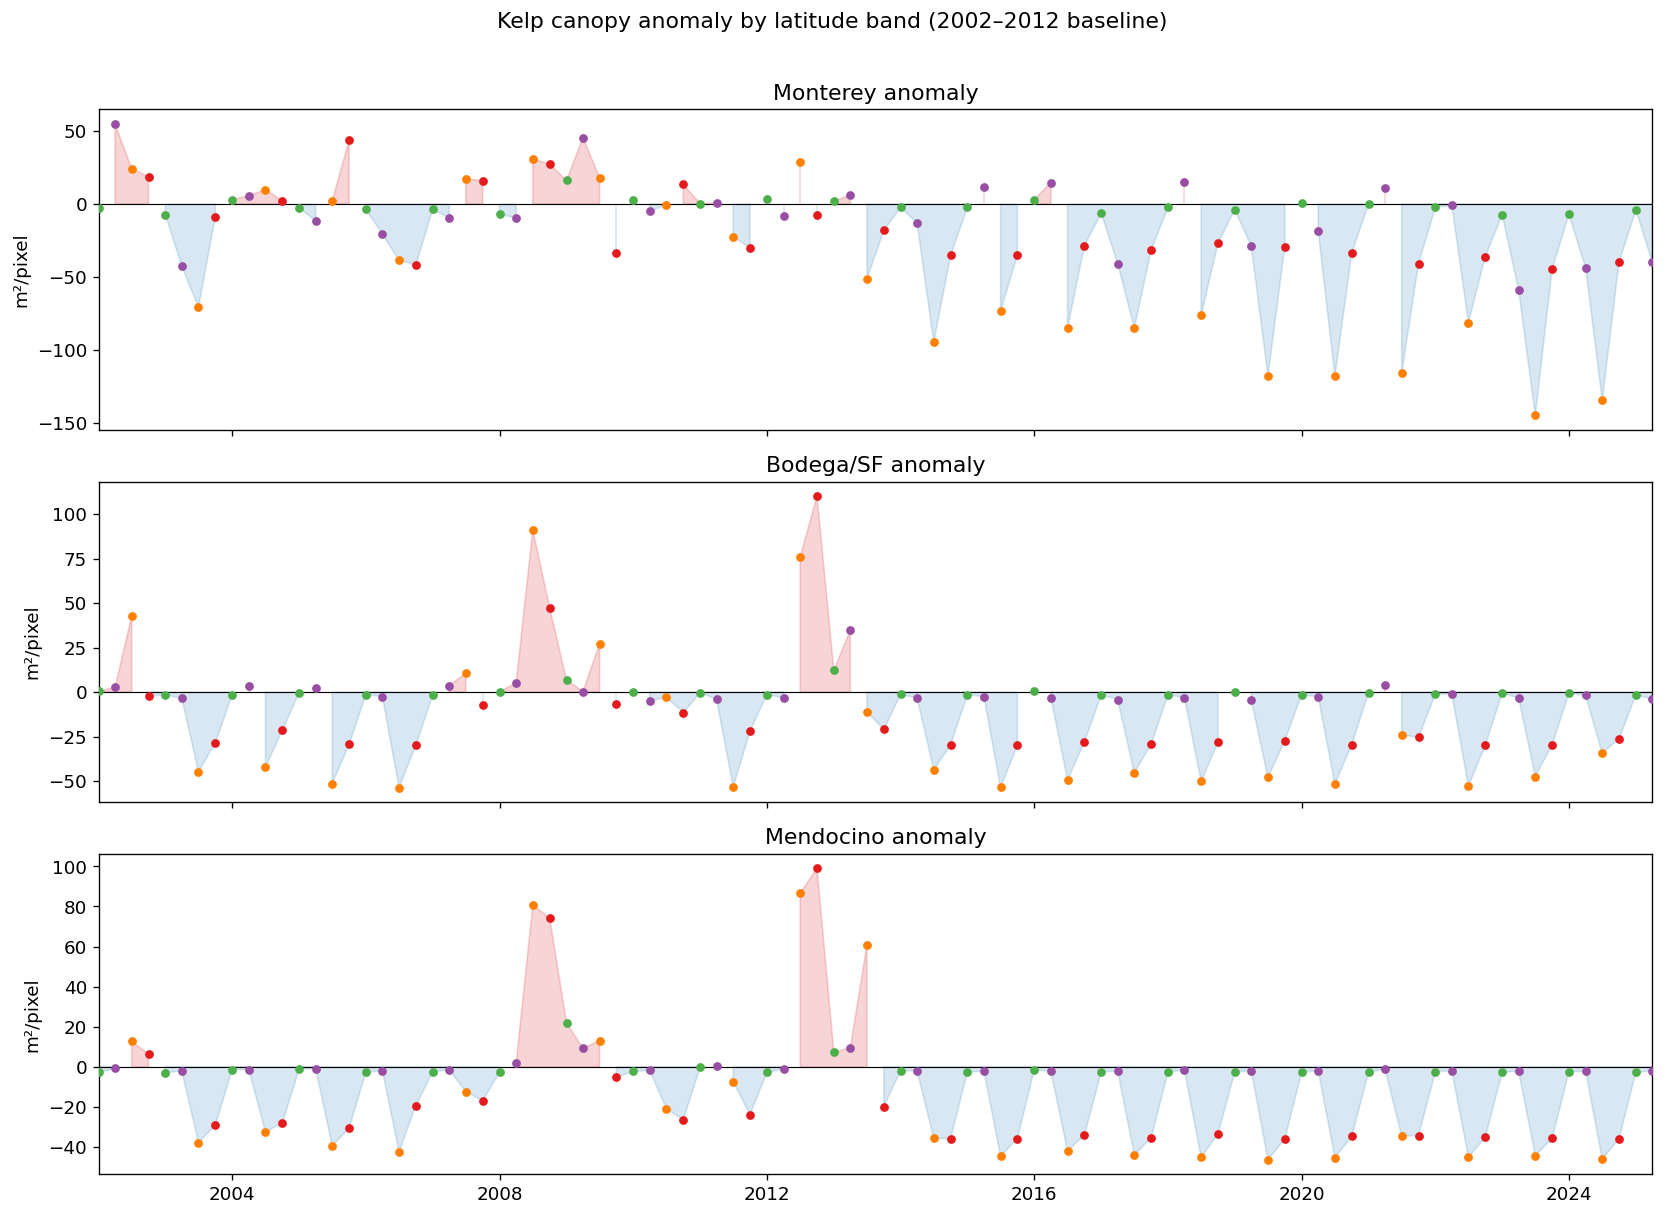

In [11]:
# ── 3.3 Lat-band anomaly time series ─────────────────────────────────────────
fig, axes = plt.subplots(len(bin_series), 1, figsize=(14, 10), sharex=True)

for ax, (label, _, _, _) in zip(axes, LAT_BINS):
    if label not in bin_series:
        ax.axis('off')
        continue
    s = pd.Series(bin_series[label], index=dates_a)
    a = quarterly_anomaly(s)
    for q in range(1, 5):
        m = qs_a == q
        ax.scatter(dates_a[m], a.values[m], color=Q_COLORS[q], s=18, zorder=3)
    ax.axhline(0, color='black', lw=0.7)
    ax.fill_between(dates_a, a.values, 0, where=a.values > 0,
                    color='#d7191c', alpha=0.18)
    ax.fill_between(dates_a, a.values, 0, where=a.values < 0,
                    color='#2c7bb6', alpha=0.18)
    ax.set_ylabel('m²/pixel')
    ax.set_title(f'{label} anomaly')
    ax.set_xlim(dates_a[0], dates_a[-1])

plt.suptitle('Kelp canopy anomaly by latitude band (2002–2012 baseline)', y=1.01)
plt.tight_layout()
plt.show()

## Section 4 — Pre vs Post-Collapse Composites

Per-quarter mean canopy area comparing the **pre-collapse baseline (2002–2012)** to the **post-collapse period (2013–present)**.

Pre-collapse  (2002–2012):  11 years
Post-collapse (2013–present): 13 years


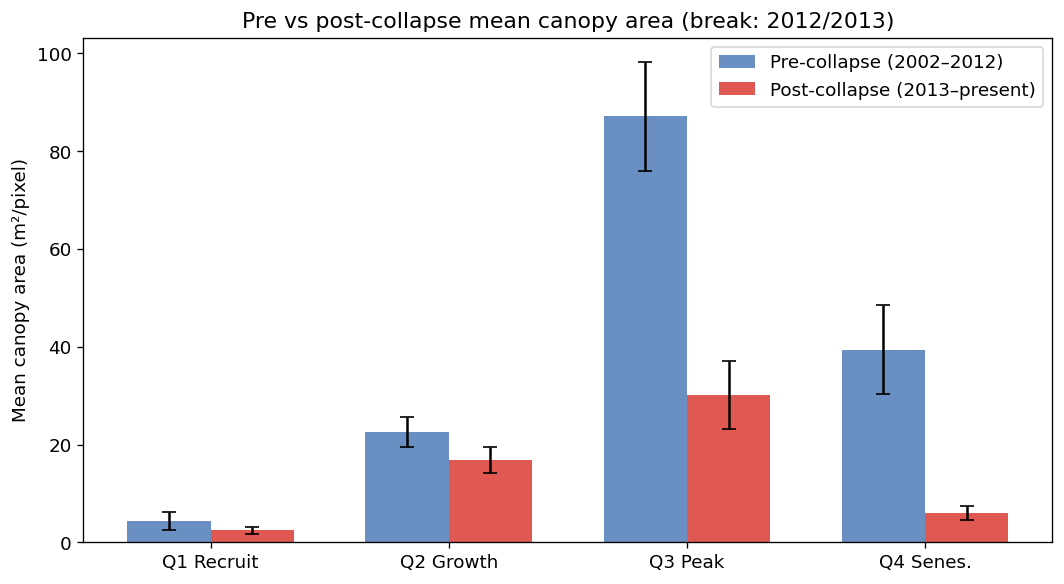


Quarter        Pre-collapse   Post-collapse        Change
---------------------------------------------------------
Q1 Recruit             4.4             2.4          -1.9 m²/px
Q2 Growth             22.5            16.9          -5.6 m²/px
Q3 Peak               87.2            30.1         -57.1 m²/px
Q4 Senes.             39.4             6.0         -33.4 m²/px


In [12]:
# ── 4.1 Pre vs post-collapse composites — domain mean ─────────────────────────
pre_mask  = yrs_a <= BASELINE_END_YR
post_mask = yrs_a >  BASELINE_END_YR

print(f'Pre-collapse  (2002–{BASELINE_END_YR}):  {len(np.unique(yrs_a[pre_mask]))} years')
print(f'Post-collapse ({BASELINE_END_YR+1}–present): {len(np.unique(yrs_a[post_mask]))} years')

fig, ax = plt.subplots(figsize=(9, 5))
x, w = np.arange(4), 0.35

for offset, mask, label, color in [
    (-w/2, pre_mask,  f'Pre-collapse (2002–{BASELINE_END_YR})',      '#4575b4'),
    ( w/2, post_mask, f'Post-collapse ({BASELINE_END_YR+1}–present)', '#d73027'),
]:
    means = [mean_area[mask & (qs_a == q)].mean() for q in range(1, 5)]
    sems  = [
        mean_area[mask & (qs_a == q)].std() /
        max(1, np.sqrt((mask & (qs_a == q)).sum()))
        for q in range(1, 5)
    ]
    ax.bar(x + offset, means, w, yerr=sems, label=label,
           color=color, alpha=0.8, capsize=4)

ax.set_xticks(x)
ax.set_xticklabels([f'Q{q} {Q_STAGE[q]}' for q in range(1, 5)])
ax.set_ylabel('Mean canopy area (m²/pixel)')
ax.set_title(f'Pre vs post-collapse mean canopy area (break: {BASELINE_END_YR}/{BASELINE_END_YR+1})')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\n{"Quarter":<12} {"Pre-collapse":>14} {"Post-collapse":>15} {"Change":>13}')
print('-' * 57)
for q in range(1, 5):
    pre_m  = mean_area[pre_mask  & (qs_a == q)].mean()
    post_m = mean_area[post_mask & (qs_a == q)].mean()
    print(f'Q{q} {Q_STAGE[q]:<8} {pre_m:>14.1f} {post_m:>15.1f} {post_m - pre_m:>+13.1f} m²/px')

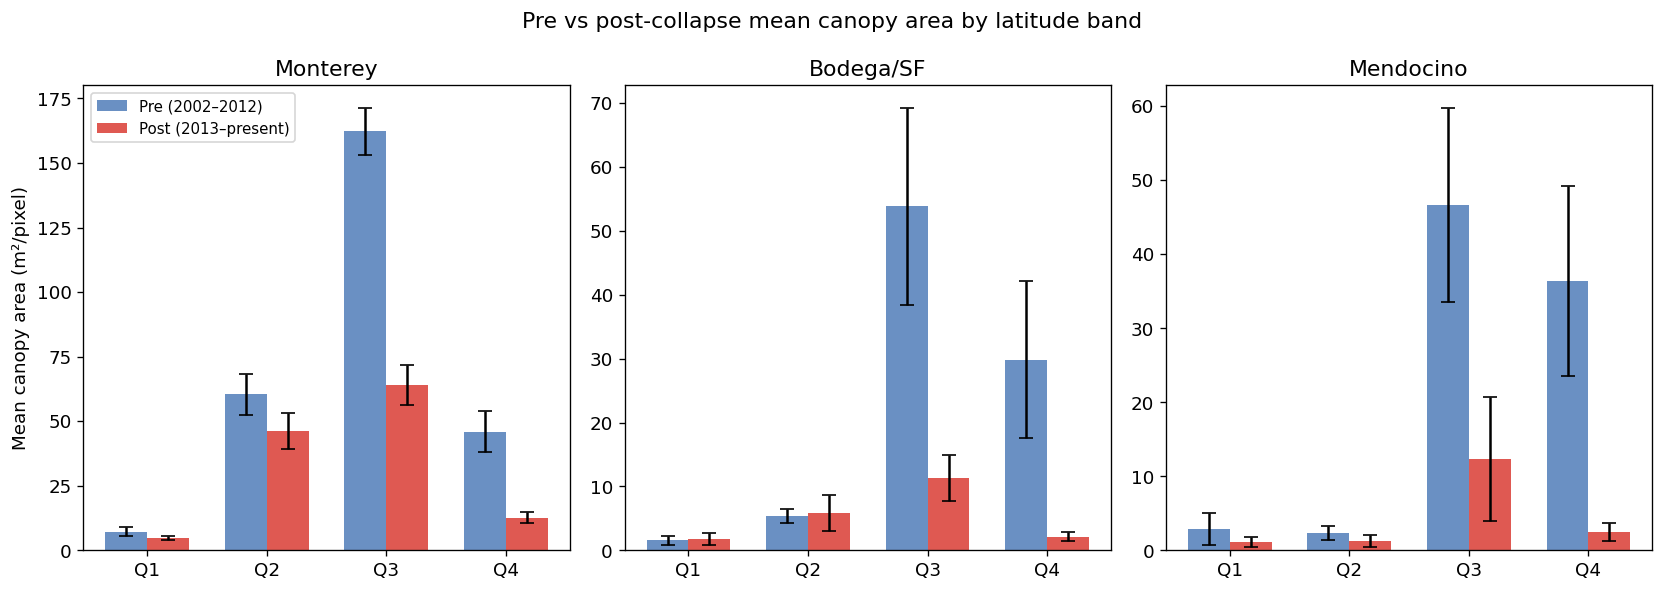

In [13]:
# ── 4.2 Pre vs post-collapse by lat band ──────────────────────────────────────
fig, axes = plt.subplots(1, len(bin_series), figsize=(14, 5), sharey=False)

for ax, (label, _, _, _) in zip(axes, LAT_BINS):
    if label not in bin_series:
        ax.axis('off')
        continue
    series = bin_series[label]
    x, w = np.arange(4), 0.35
    for offset, mask, lbl, color in [
        (-w/2, pre_mask,  f'Pre (2002–{BASELINE_END_YR})',      '#4575b4'),
        ( w/2, post_mask, f'Post ({BASELINE_END_YR+1}–present)', '#d73027'),
    ]:
        means = [series[mask & (qs_a == q)].mean() for q in range(1, 5)]
        sems  = [
            series[mask & (qs_a == q)].std() /
            max(1, np.sqrt((mask & (qs_a == q)).sum()))
            for q in range(1, 5)
        ]
        ax.bar(x + offset, means, w, yerr=sems, label=lbl,
               color=color, alpha=0.8, capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Q{q}' for q in range(1, 5)])
    ax.set_title(label)

axes[0].set_ylabel('Mean canopy area (m²/pixel)')
axes[0].legend(fontsize=9)
plt.suptitle('Pre vs post-collapse mean canopy area by latitude band')
plt.tight_layout()
plt.show()

## Section 5 — Trend Analysis

Per-quarter OLS linear trends over the full analysis window (2002–present). Red bars: p < 0.05.

**Note on methodology:** OLS detects a linear slope across the full record. For species/bands where the decline is a step-change (cliff) rather than a gradual slope, OLS will show a weak, non-significant trend even when the magnitude of change is large. Section 5.3 uses a pre/post break Mann-Whitney U test as the appropriate complement for detecting step-changes.

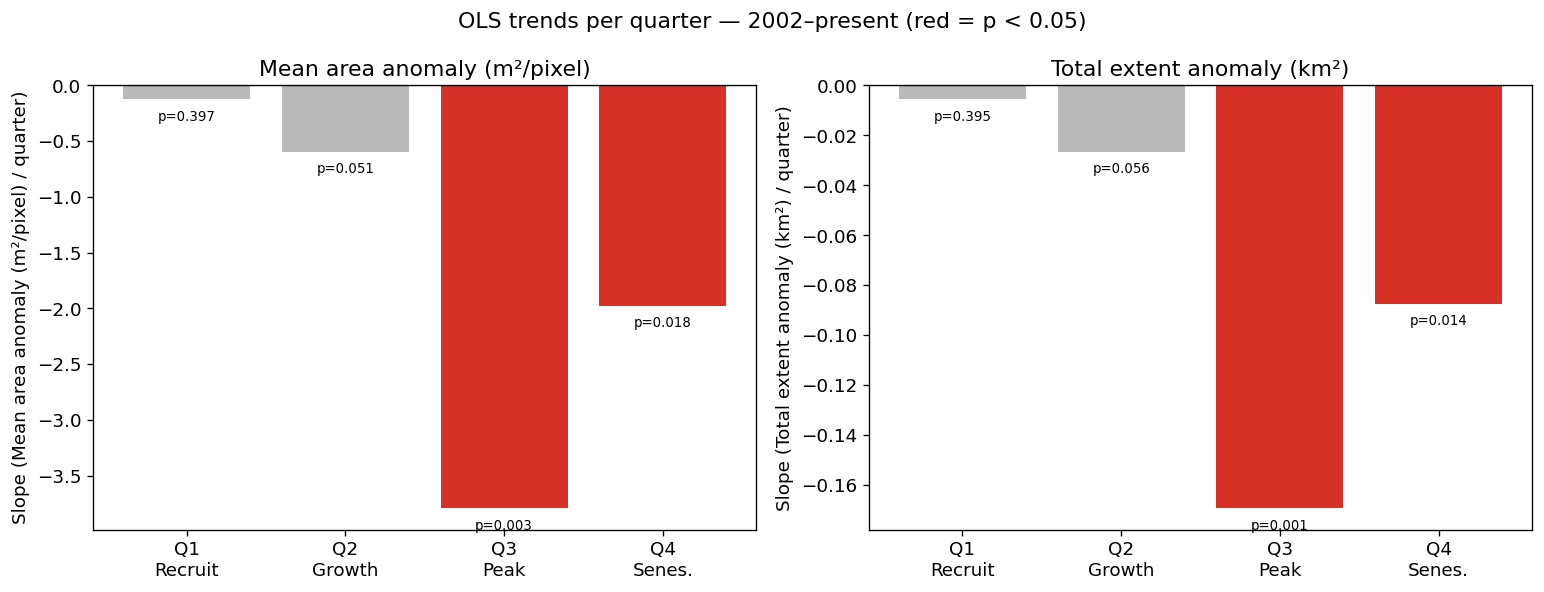


Quarter           Slope (m²/px/qtr)        p
--------------------------------------------
Q1 Recruit                 -0.1242    0.397   
Q2 Growth                  -0.5978    0.051   
Q3 Peak                    -3.7947    0.003 **
Q4 Senes.                  -1.9753    0.018 **


In [14]:
# ── 5.1 Per-quarter OLS trends — domain mean ──────────────────────────────────
anom_ext = quarterly_anomaly(pd.Series(ext_km2, index=dates_a))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (series_label, series_vals) in zip(axes, [
    ('Mean area anomaly (m²/pixel)', anom.values),
    ('Total extent anomaly (km²)',   anom_ext.values),
]):
    slopes, ps, labels = [], [], []
    for q in range(1, 5):
        sub = series_vals[qs_a == q]
        slope, p = ols_trend(pd.Series(sub))
        slopes.append(slope); ps.append(p)
        labels.append(f'Q{q}\n{Q_STAGE[q]}')
    colors = ['#d73027' if p < 0.05 else '#bababa' for p in ps]
    ax.bar(labels, slopes, color=colors)
    ax.axhline(0, color='black', lw=0.7)
    ax.set_ylabel(f'Slope ({series_label} / quarter)')
    ax.set_title(series_label)
    for i, (s, p) in enumerate(zip(slopes, ps)):
        yoff = np.sign(s) * abs(max(slopes, key=abs)) * 0.05 if max(slopes, key=abs) != 0 else 0
        ax.text(i, s + yoff, f'p={p:.3f}', ha='center', fontsize=8)

plt.suptitle('OLS trends per quarter — 2002–present (red = p < 0.05)')
plt.tight_layout()
plt.show()

print(f'\n{"Quarter":<14} {"Slope (m²/px/qtr)":>20} {"p":>8}')
print('-' * 44)
for q in range(1, 5):
    sub = anom.values[qs_a == q]
    slope, p = ols_trend(pd.Series(sub))
    sig = '**' if p < 0.05 else '  '
    print(f'Q{q} {Q_STAGE[q]:<10} {slope:>20.4f} {p:>8.3f} {sig}')

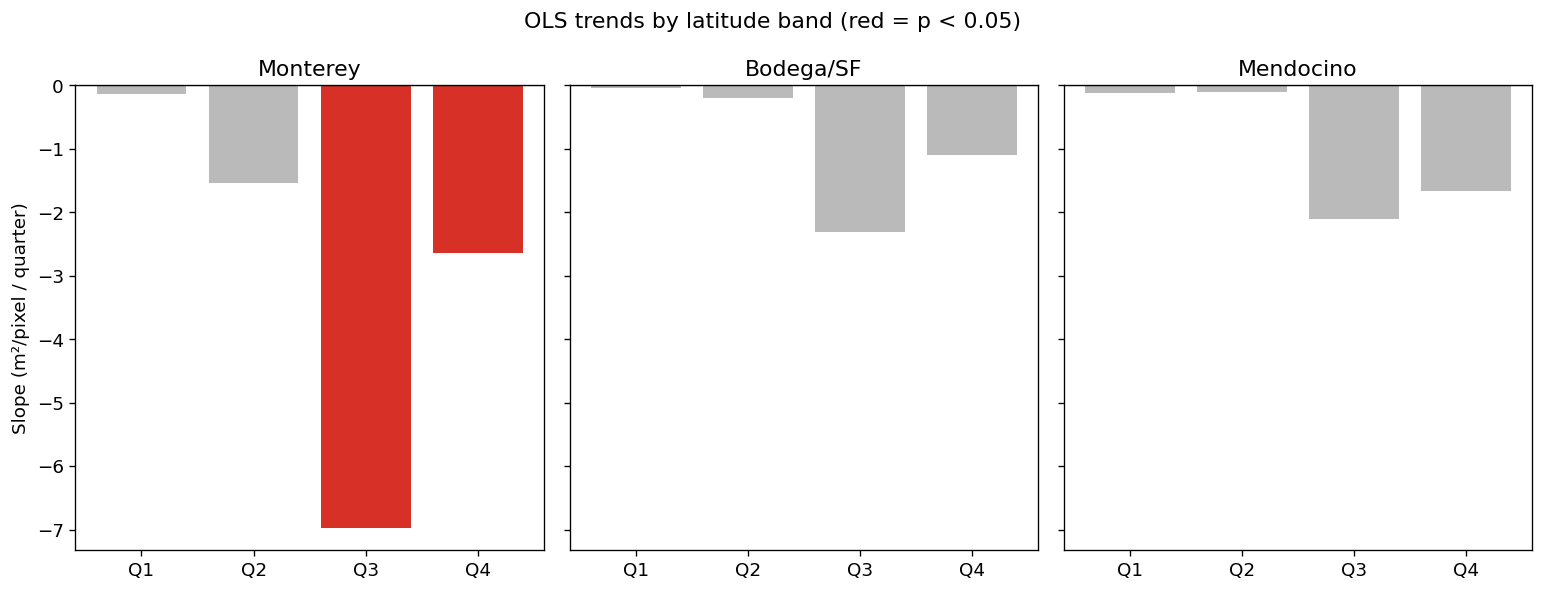


Quarter                           Monterey                   Bodega/SF                   Mendocino
--------------------------------------------------------------------------------------------------
Q1 Recruit       -0.140  p=0.360       -0.038  p=0.689       -0.120  p=0.454   
Q2 Growth        -1.531  p=0.055       -0.198  p=0.414       -0.102  p=0.291   
Q3 Peak          -6.976  p=0.000 ✱✱    -2.315  p=0.089       -2.102  p=0.107   
Q4 Senes.        -2.634  p=0.000 ✱✱    -1.099  p=0.285       -1.669  p=0.130   


In [15]:
# ── 5.2 Per-quarter trends by lat band ────────────────────────────────────────
fig, axes = plt.subplots(1, len(bin_series), figsize=(13, 5), sharey=True)

for ax, (label, _, _, _) in zip(axes, LAT_BINS):
    if label not in bin_series:
        ax.axis('off')
        continue
    a = quarterly_anomaly(pd.Series(bin_series[label], index=dates_a))
    slopes, ps = [], []
    for q in range(1, 5):
        slope, p = ols_trend(pd.Series(a.values[qs_a == q]))
        slopes.append(slope); ps.append(p)
    colors = ['#d73027' if p < 0.05 else '#bababa' for p in ps]
    ax.bar([f'Q{q}' for q in range(1, 5)], slopes, color=colors)
    ax.axhline(0, color='black', lw=0.7)
    ax.set_title(label)

axes[0].set_ylabel('Slope (m²/pixel / quarter)')
plt.suptitle('OLS trends by latitude band (red = p < 0.05)')
plt.tight_layout()
plt.show()

# ── Significance table ─────────────────────────────────────────────────────────
bands = [label for label, _, _, _ in LAT_BINS if label in bin_series]
print(f'\n{"Quarter":<14}', end='')
for label in bands:
    print(f'  {label:>26}', end='')
print()
print('-' * (14 + 28 * len(bands)))
for q in range(1, 5):
    print(f'Q{q} {Q_STAGE[q]:<10}', end='')
    for label in bands:
        a = quarterly_anomaly(pd.Series(bin_series[label], index=dates_a))
        slope, p = ols_trend(pd.Series(a.values[qs_a == q]))
        sig = ' ✱✱' if p < 0.01 else (' ✱ ' if p < 0.05 else '   ')
        print(f'  {slope:>+8.3f}  p={p:.3f}{sig}', end='')
    print()

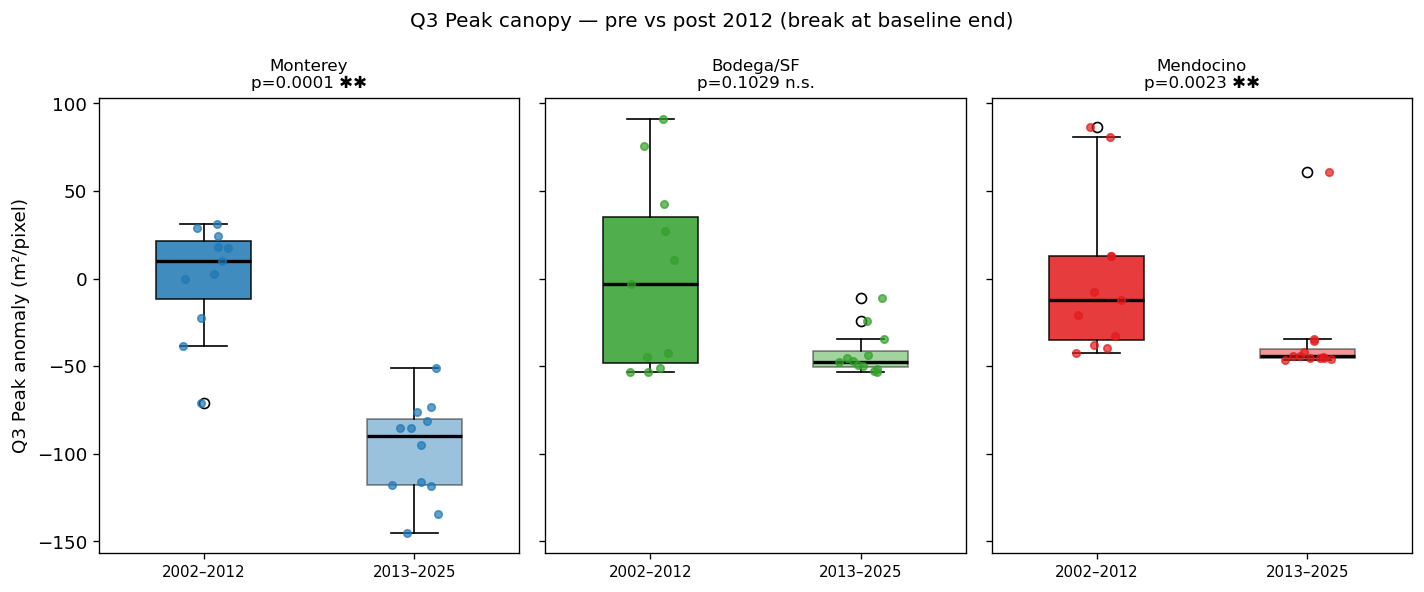

Pre/post break: 2002–2012 vs 2013–2025

Monterey:
  Quarter          Pre mean  Post mean          Δ       p (MW)
  ----------------------------------------------------------
  Q1 Recruit         -0.00      -2.39      -2.39     p=0.4869
  Q2 Growth          +0.00     -14.29     -14.29     p=0.4869
  Q3 Peak            +0.00     -98.24     -98.24 ✱✱  p=0.0001
  Q4 Senes.          +0.00     -33.27     -33.27 ✱✱  p=0.0062

Bodega/SF:
  Quarter          Pre mean  Post mean          Δ       p (MW)
  ----------------------------------------------------------
  Q1 Recruit         +0.00      +0.23      +0.23     p=1.0000
  Q2 Growth          -0.00      +0.43      +0.43     p=0.3848
  Q3 Peak            +0.00     -42.55     -42.55     p=0.1029
  Q4 Senes.          -0.00     -27.72     -27.72 ✱   p=0.0127

Mendocino:
  Quarter          Pre mean  Post mean          Δ       p (MW)
  ----------------------------------------------------------
  Q1 Recruit         -0.00      -1.77      -1.77     p=0.8

In [16]:
# ── 5.3 Pre/post break comparison — Mann-Whitney U ────────────────────────────
# OLS detects linear slope; a step-change at the collapse year (~2013) has
# near-zero slope but enormous mean difference. Mann-Whitney U is the right
# test: non-parametric, no linearity assumption, sensitive to a shift in
# location regardless of the shape of the change.
from scipy.stats import mannwhitneyu

BREAK_YR = BASELINE_END_YR  # pre: 2002–2012   post: 2013–2025

# ── Q3 distribution by lat band: box + raw points ────────────────────────────
bands = [(label, color) for label, _, _, color in LAT_BINS if label in bin_series]
fig, axes = plt.subplots(1, len(bands), figsize=(12, 5), sharey=True)

for ax, (label, color) in zip(axes, bands):
    a = quarterly_anomaly(pd.Series(bin_series[label], index=dates_a))
    pre  = a.values[(qs_a == 3) & (yrs_a <= BREAK_YR)]
    post = a.values[(qs_a == 3) & (yrs_a >  BREAK_YR)]

    bp = ax.boxplot([pre, post], patch_artist=True, widths=0.45,
                    medianprops=dict(color='black', lw=2))
    for patch, alpha in zip(bp['boxes'], [0.85, 0.45]):
        patch.set_facecolor(color); patch.set_alpha(alpha)

    rng = np.random.default_rng(42)
    for vals, xc in [(pre, 1), (post, 2)]:
        jitter = rng.uniform(-0.12, 0.12, len(vals))
        ax.scatter(xc + jitter, vals, color=color, s=20, alpha=0.7, zorder=3)

    _, p = mannwhitneyu(pre, post, alternative='two-sided')
    sig  = '✱✱' if p < 0.01 else ('✱' if p < 0.05 else 'n.s.')
    ax.set_title(f'{label}\np={p:.4f} {sig}', fontsize=10)
    ax.set_xticks([1, 2])
    ax.set_xticklabels([f'2002–{BREAK_YR}', f'{BREAK_YR+1}–2025'], fontsize=9)

axes[0].set_ylabel('Q3 Peak anomaly (m²/pixel)')
plt.suptitle(f'Q3 Peak canopy — pre vs post {BREAK_YR} (break at baseline end)',
             fontsize=12)
plt.tight_layout()
plt.show()

# ── Full table: all quarters × all bands ─────────────────────────────────────
print(f'Pre/post break: 2002–{BREAK_YR} vs {BREAK_YR+1}–2025\n')
for label, _ in bands:
    a = quarterly_anomaly(pd.Series(bin_series[label], index=dates_a))
    print(f'{label}:')
    print(f'  {"Quarter":<14} {"Pre mean":>10} {"Post mean":>10} '
          f'{"Δ":>10} {"p (MW)":>12}')
    print('  ' + '-' * 58)
    for q in range(1, 5):
        pre  = a.values[(qs_a == q) & (yrs_a <= BREAK_YR)]
        post = a.values[(qs_a == q) & (yrs_a >  BREAK_YR)]
        diff = post.mean() - pre.mean()
        _, p = mannwhitneyu(pre, post, alternative='two-sided')
        sig  = ' ✱✱' if p < 0.01 else (' ✱ ' if p < 0.05 else '   ')
        print(f'  Q{q} {Q_STAGE[q]:<10} {pre.mean():>+10.2f} {post.mean():>+10.2f} '
              f'{diff:>+10.2f}{sig}  p={p:.4f}')
    print()

## Section 5.4 — Post-Collapse OLS: Monterey Giant Kelp

Full-record OLS slope (Section 5.1–5.2) is dominated by the 2012→2013 step-change — the regression line spans both the high pre-collapse and low post-collapse clusters, so the slope primarily captures the one-time drop rather than ongoing erosion. Fitting OLS on **2013–present only** tests whether the decline is continuing within the post-collapse period or whether Monterey has stabilised at a lower level.

Monterey — post-collapse OLS (2013–present)

Quarter           Slope (m²/px/qtr)        p  Verdict
-----------------------------------------------------------------
Q1 Recruit                 -0.4510  p=0.060  flat — no significant trend
Q2 Growth                  -3.7851  p=0.043  ongoing erosion **
Q3 Peak                    -6.0152  p=0.003  ongoing erosion **
Q4 Senes.                  -1.3928  p=0.010  ongoing erosion **


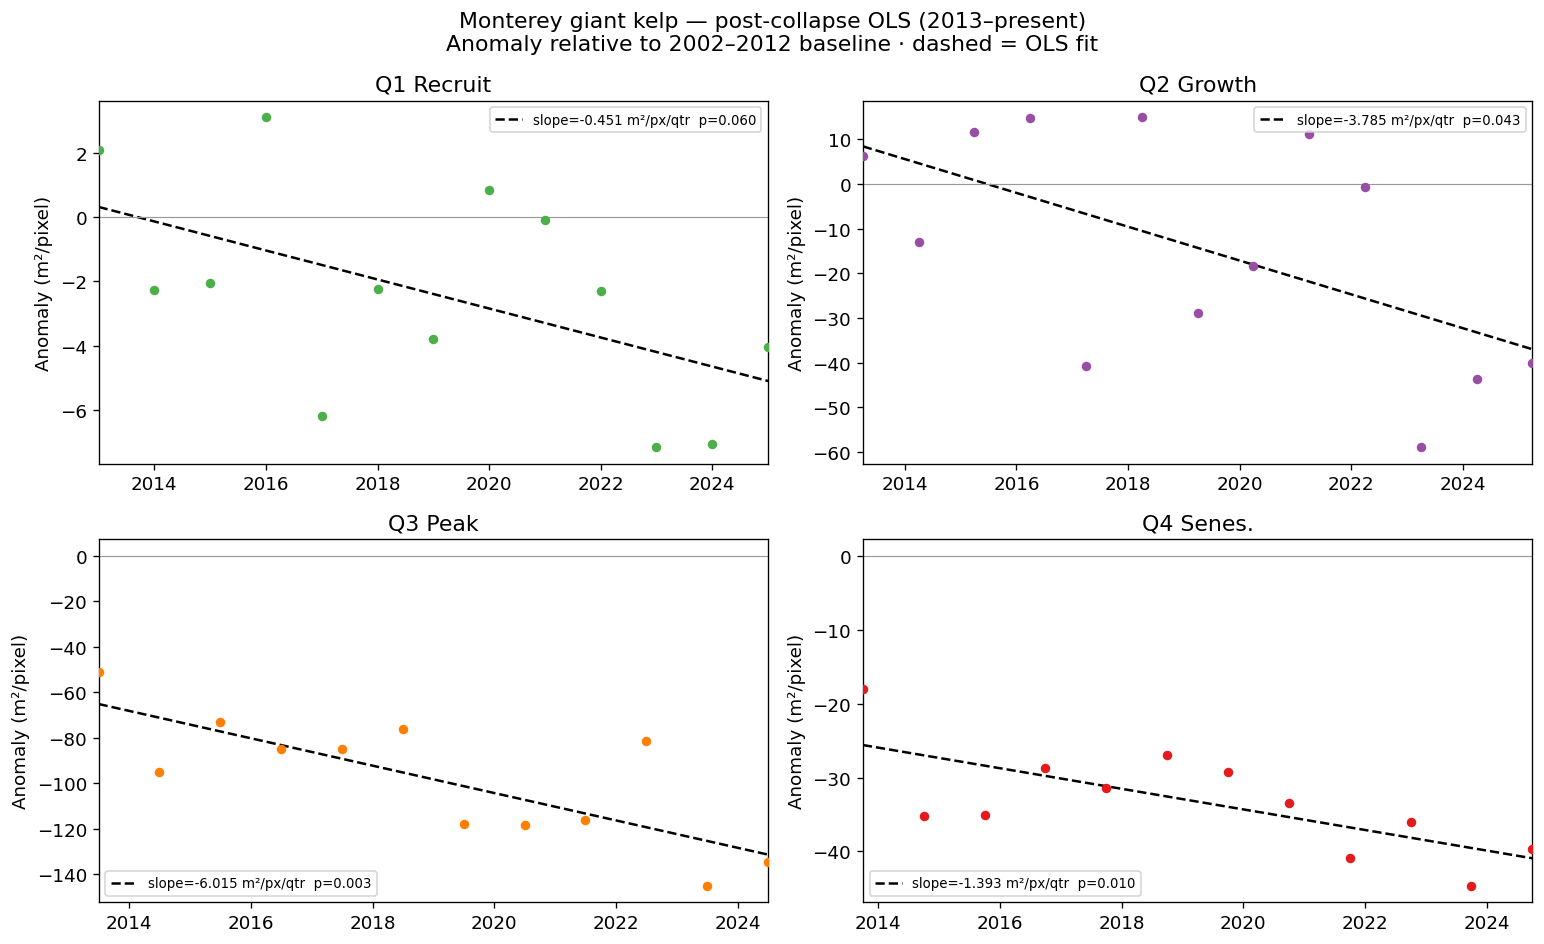

In [17]:
# ── 5.4 Post-collapse OLS — Monterey giant kelp ───────────────────────────────
post_mask_ols = yrs_a > BASELINE_END_YR
a_mont = quarterly_anomaly(pd.Series(bin_series['Monterey'], index=dates_a))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

print(f'Monterey — post-collapse OLS ({BASELINE_END_YR + 1}–present)\n')
print(f'{"Quarter":<14} {"Slope (m²/px/qtr)":>20} {"p":>8}  Verdict')
print('-' * 65)

for i, q in enumerate(range(1, 5)):
    q_mask    = (qs_a == q) & post_mask_ols
    sub_vals  = a_mont.values[q_mask]
    sub_dates = dates_a[q_mask]

    slope, p = ols_trend(pd.Series(sub_vals))
    verdict  = 'ongoing erosion **' if p < 0.05 else 'flat — no significant trend'
    print(f'Q{q} {Q_STAGE[q]:<10} {slope:>+20.4f}  p={p:.3f}  {verdict}')

    ax = axes[i]
    ax.scatter(sub_dates, sub_vals, color=Q_COLORS[q], s=22, zorder=3)
    if not np.isnan(slope):
        x_num = np.arange(len(sub_vals))
        res   = _scipy_stats.linregress(x_num, sub_vals)
        trend_line = res.slope * x_num + res.intercept
        lbl = f'slope={slope:+.3f} m²/px/qtr  p={p:.3f}'
        ax.plot(sub_dates, trend_line, color='black', lw=1.5, ls='--', label=lbl)
    ax.axhline(0, color='0.6', lw=0.7)
    ax.set_title(f'Q{q} {Q_STAGE[q]}')
    ax.set_ylabel('Anomaly (m²/pixel)')
    ax.legend(fontsize=8)
    ax.set_xlim(sub_dates[0], sub_dates[-1])

plt.suptitle(f'Monterey giant kelp — post-collapse OLS ({BASELINE_END_YR + 1}–present)\n'
             'Anomaly relative to 2002–2012 baseline · dashed = OLS fit')
plt.tight_layout()
plt.show()

## Section 5b — Monterey Biomass vs Canopy Area

Giant kelp biomass (`kg wet wt/pixel`) tracks standing crop — vertical canopy density × extent. Comparing it to canopy area reveals whether the decline is driven by **patch loss** (area and biomass drop proportionally, footprint shrinks) or **canopy thinning** (biomass drops faster than area, the geographic footprint persists but stipes are sparse).

> Biomass covers giant kelp (*Macrocystis pyrifera*) only — ecologically meaningful for the **Monterey bin** (36.5–37.8°N). Bull kelp biomass is not provided in this dataset.

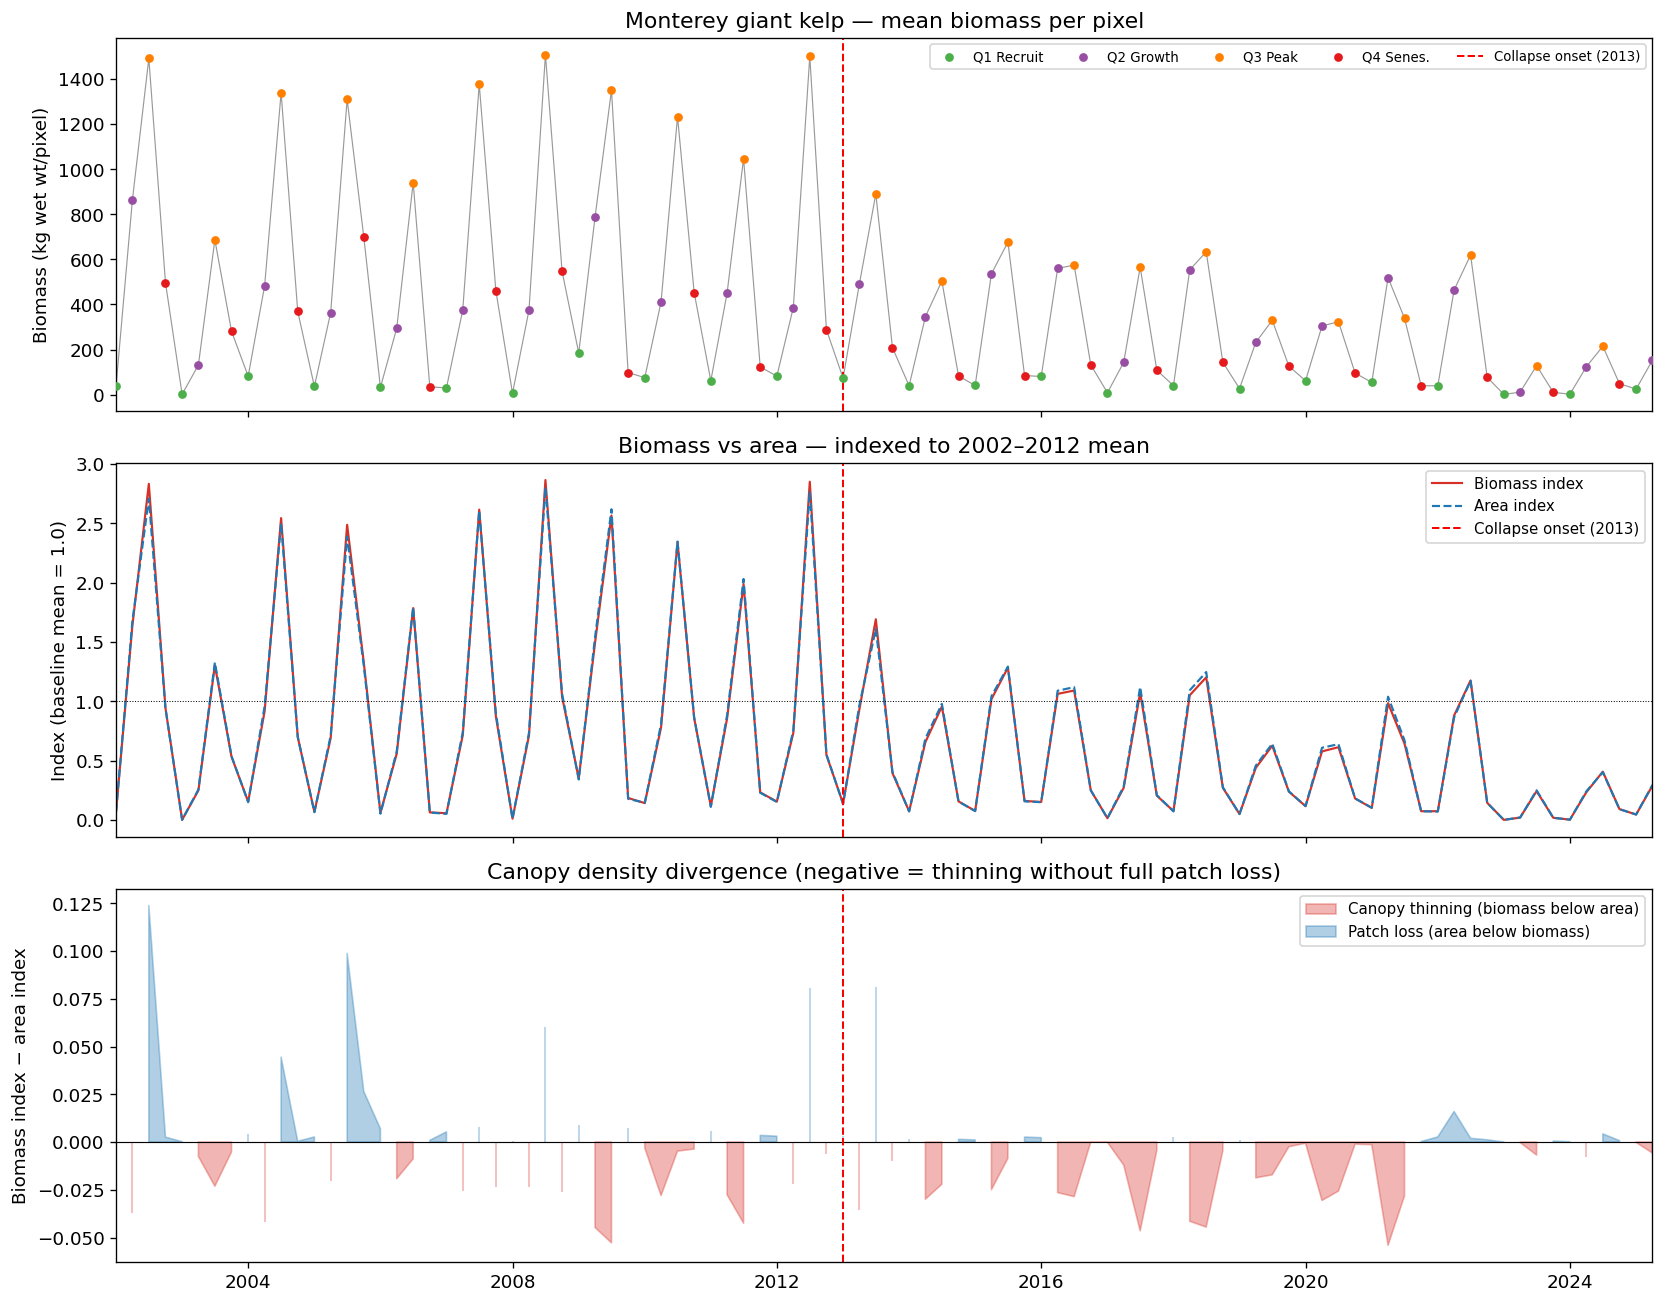


Quarter                    Area slope            Biomass slope
----------------------------------------------------------------
Q1 Recruit       -0.140 m²/px/qtr (p=0.360)        -1.163 kg/px/qtr  (p=0.327)   
Q2 Growth        -1.531 m²/px/qtr (p=0.055)       -11.298 kg/px/qtr  (p=0.057)   
Q3 Peak          -6.976 m²/px/qtr (p=0.000) ✱✱    -55.056 kg/px/qtr  (p=0.000) ✱✱
Q4 Senes.        -2.634 m²/px/qtr (p=0.000) ✱✱    -20.101 kg/px/qtr  (p=0.000) ✱✱


In [18]:
# ── 5b. Monterey biomass vs canopy area ───────────────────────────────────────
if 'biomass' not in ds_a.data_vars:
    print('[SKIP] Biomass not in dataset — re-run the ETL cell to regenerate the cache.')
else:
    mont_idx = np.where(
        (ds_a['latitude'].values >= 36.5) & (ds_a['latitude'].values < 37.8)
    )[0]
    ds_mont  = ds_a.isel(station=mont_idx)

    bio_vals = ds_mont['biomass'].values.copy().astype(float)
    bio_vals[ds_mont['passes'].values == 0] = np.nan
    bio_mean  = np.nanmean(bio_vals, axis=1)
    area_mont = bin_series['Monterey']

    # Index both to their 2002-2012 baseline mean for direct comparison
    base_m   = yrs_a <= BASELINE_END_YR
    bio_idx  = bio_mean  / np.nanmean(bio_mean[base_m])
    area_idx = area_mont / np.nanmean(area_mont[base_m])

    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

    # Panel 1: raw biomass
    for q in range(1, 5):
        m = qs_a == q
        axes[0].scatter(dates_a[m], bio_mean[m], color=Q_COLORS[q], s=18,
                        label=f'Q{q} {Q_STAGE[q]}', zorder=3)
    axes[0].plot(dates_a, bio_mean, color='0.6', lw=0.7, zorder=1)
    axes[0].axvline(COLLAPSE_LINE, color='red', lw=1.2, ls='--', label='Collapse onset (2013)')
    axes[0].set_ylabel('Biomass (kg wet wt/pixel)')
    axes[0].set_title('Monterey giant kelp — mean biomass per pixel')
    axes[0].legend(ncol=5, fontsize=8)

    # Panel 2: indexed comparison (baseline mean = 1)
    axes[1].plot(dates_a, bio_idx,  color='#d73027', lw=1.3, label='Biomass index')
    axes[1].plot(dates_a, area_idx, color='#1f78b4', lw=1.3, ls='--', label='Area index')
    axes[1].axhline(1, color='black', lw=0.6, ls=':')
    axes[1].axvline(COLLAPSE_LINE, color='red', lw=1.2, ls='--', label='Collapse onset (2013)')
    axes[1].set_ylabel('Index (baseline mean = 1.0)')
    axes[1].set_title('Biomass vs area — indexed to 2002–2012 mean')
    axes[1].legend(fontsize=9)

    # Panel 3: divergence — negative = canopy thinning (biomass < area index)
    div = bio_idx - area_idx
    axes[2].fill_between(dates_a, div, 0,
                         where=div < 0, color='#d73027', alpha=0.35,
                         label='Canopy thinning (biomass below area)')
    axes[2].fill_between(dates_a, div, 0,
                         where=div >= 0, color='#1f78b4', alpha=0.35,
                         label='Patch loss (area below biomass)')
    axes[2].axhline(0, color='black', lw=0.7)
    axes[2].axvline(COLLAPSE_LINE, color='red', lw=1.2, ls='--')
    axes[2].set_ylabel('Biomass index − area index')
    axes[2].set_title('Canopy density divergence (negative = thinning without full patch loss)')
    axes[2].legend(fontsize=9)

    for ax in axes:
        ax.set_xlim(dates_a[0], dates_a[-1])
    plt.tight_layout()
    plt.show()

    # OLS comparison: area vs biomass per quarter
    anom_bio  = quarterly_anomaly(pd.Series(bio_mean,  index=dates_a))
    anom_area = quarterly_anomaly(pd.Series(area_mont, index=dates_a))

    print(f'\n{"Quarter":<14} {"Area slope":>22} {"Biomass slope":>24}')
    print('-' * 64)
    for q in range(1, 5):
        a_sl, a_p = ols_trend(pd.Series(anom_area.values[qs_a == q]))
        b_sl, b_p = ols_trend(pd.Series(anom_bio.values[qs_a == q]))
        a_sig = ' ✱✱' if a_p < 0.01 else (' ✱ ' if a_p < 0.05 else '   ')
        b_sig = ' ✱✱' if b_p < 0.01 else (' ✱ ' if b_p < 0.05 else '   ')
        print(f'Q{q} {Q_STAGE[q]:<10} '
              f'{a_sl:>+9.3f} m²/px/qtr (p={a_p:.3f}){a_sig}  '
              f'{b_sl:>+9.3f} kg/px/qtr  (p={b_p:.3f}){b_sig}')

## Section 6 — Summary of Findings

Key results from the KelpWatch Landsat EDA for the Monterey–Mendocino kelp coast (2002–present).

---

### Domain overview
- **45,564 pixels** across Monterey → Mendocino (36.5–40°N); 94 quarters, 2002 Q1 – 2025 Q2
- `area` captures both *Macrocystis* and *Nereocystis* combined; latitude bands serve as species proxy
- Data quality: no analysis-window quarters exceed the 20% zero-pass threshold; L7 SLC failure (May 2003) caused a 16% pass reduction, offset by L8/9 OLI from 2013

### Canopy record (Q3 Peak season)
- **Best Q3 on record:** 156.6 m²/pixel, 6.82 km² total extent — **2012 Q3**, the final summer before collapse
- **Worst Q3 on record:** 7.7 m²/pixel, 0.35 km² total extent — **2023 Q3**; peak anomaly −79.5 m²/pixel
- Collapse onset at 2013 is visible across all time series and heatmaps as a sharp transition

### Species contrast — Monterey vs Mendocino
- **Monterey (giant kelp, 36.5–37.8°N):** mean 49.1 m²/pixel — ~4× higher density than northern bins, consistent with *Macrocystis*'s perennial, multi-stipe canopy
- **Mendocino (bull kelp, 38.5–40°N):** mean 12.6 m²/pixel — highest pixel count (28k) but lower canopy density; higher interannual variance expected for an annual species
- **Collapse character differs by species:** Monterey suffered a large step-change and continues to erode; Mendocino collapsed abruptly and shows no detectable further decline — it is largely absent rather than continuing to thin
- **Bodega/SF transition zone (37.8–38.5°N):** mean 13.4 m²/pixel; Mann-Whitney Q3 non-significant (p=0.10) — mixed species and low pixel count limit statistical power

### Pre vs post-collapse composites (Section 4)

| Quarter | Pre-collapse (2002–2012) | Post-collapse (2013–present) | Change | % loss |
|---|---|---|---|---|
| Q2 Growth | 22.5 m²/px | 16.9 m²/px | −5.6 m²/px | −25% |
| **Q3 Peak** | **87.2 m²/px** | **30.1 m²/px** | **−57.1 m²/px** | **−65%** |
| Q4 Senes. | 39.4 m²/px | 6.0 m²/px | −33.4 m²/px | −85% |

- **Q3 Peak** shows the largest absolute loss (−57 m²/px, −65%); **Q4 Senescence** shows the largest proportional loss (−85%) — post-collapse senescence canopy (6.0 m²/px) has collapsed to near winter-recruit levels
- **Q2 Growth** step-change (−25%) indicates recruitment failure, not just loss of peak-season canopy
- Q1 Recruit excluded — near-zero kelp in all years, pre- and post-collapse

### Trend analysis (Sections 5.1–5.4)

**Two collapse modes requiring different statistical approaches:**

| Species | Collapse mode | Test | Key result |
|---|---|---|---|
| Giant kelp (*Macrocystis*, Monterey) | Step-change + ongoing post-collapse erosion | OLS + post-collapse OLS | Full-record Q3: −6.98 m²/px/qtr p<0.001; post-2012 Q3: −6.02 p=0.003 |
| Bull kelp (*Nereocystis*, Mendocino) | Abrupt cliff then flat | Mann-Whitney | Q3 p=0.0023, Q4 p=0.0002, Q2 p=0.0077 |

- **Full-record OLS (5.1–5.2):** Monterey Q3 and Q4 significant (p<0.001); Mendocino non-significant — OLS misses the cliff because a step-change produces near-zero average slope
- **Mann-Whitney pre/post 2012 (5.3):** Highly significant for Monterey (Q3 p=0.0001, Q4 p=0.0062) and Mendocino (Q3 p=0.0023, Q4 p=0.0002, Q2 p=0.0077). Mendocino Q2 significance indicates the collapse extended into the spring recruitment window — bull kelp failed to recruit post-collapse, not just to sustain peak canopy
- **Post-collapse OLS — Monterey (5.4):** Q3 −6.02 m²/px/qtr (p=0.003), Q2 −3.79 (p=0.043), Q4 −1.39 (p=0.010) — Monterey giant kelp has not stabilised at a lower level; decline is ongoing across all productive quarters

### Biomass vs canopy area — Monterey giant kelp (Section 5b)

Q3 and Q4 show significant decline in both area and biomass. Indexed to the 2002–2012 baseline mean, biomass fell further below 1.0 than area in the post-collapse period — indicating canopy thinning rather than proportional patch loss:

| Quarter | Area slope | Biomass slope |
|---|---|---|
| **Q3 Peak** | **−6.98 m²/px/qtr p<0.001** | **−55.06 kg/px/qtr p<0.001** |
| **Q4 Senes.** | **−2.63 m²/px/qtr p<0.001** | **−20.10 kg/px/qtr p<0.001** |

- **Decline mode: canopy thinning.** The geographic footprint of Monterey giant kelp patches persists post-collapse, but canopy density (stipes per pixel) is declining faster than patch extent. Patches are present but increasingly sparse.

### Synthesis
Monterey (*Macrocystis*) and Mendocino (*Nereocystis*) experienced structurally different collapses at the 2012/2013 transition. Giant kelp declined through a large step-change and has continued to erode across all productive quarters since — Q3 Peak is losing ~6 m²/pixel per quarter within the post-collapse period alone, with canopy thinning outpacing patch-level loss. Bull kelp collapsed more abruptly: the Mann-Whitney cliff extends into Q2 (spring recruitment), indicating the population failed to recruit post-collapse rather than simply losing standing canopy. Since 2013, Mendocino shows no further detectable trend — the signal is absence, not ongoing decline.

## Section 7 — Kelp Canopy on Satellite Basemap: Baseline vs Stress Year

Side-by-side comparison of the best and worst Peak-season (Q3) quarters in the analysis record, for the **Mendocino coast** (38.5–40°N, bull kelp territory).

- **Satellite basemap:** USGS National Map imagery (WMS, public — no auth required). Current-date composite; coastline geography is static, so it serves as a consistent spatial reference for both years.
- **Kelp overlay:** KelpWatch canopy area (m²/pixel) for that specific quarter; pixels with zero passes excluded.
- **Baseline year:** highest Q3 total canopy extent in 2002–2012.
- **Stress year:** lowest Q3 extent across the five stress years (2014, 2022–2025).

Baseline year: 2008 Q3  (6.82 km²)
Stress year:   2023 Q3  (0.35 km²)
Anchor pixel: 39.3282°N  -123.8130°E  area=900 m²
Basemap: (700, 700) px
Pixels in bbox — baseline: 690  stress: 712


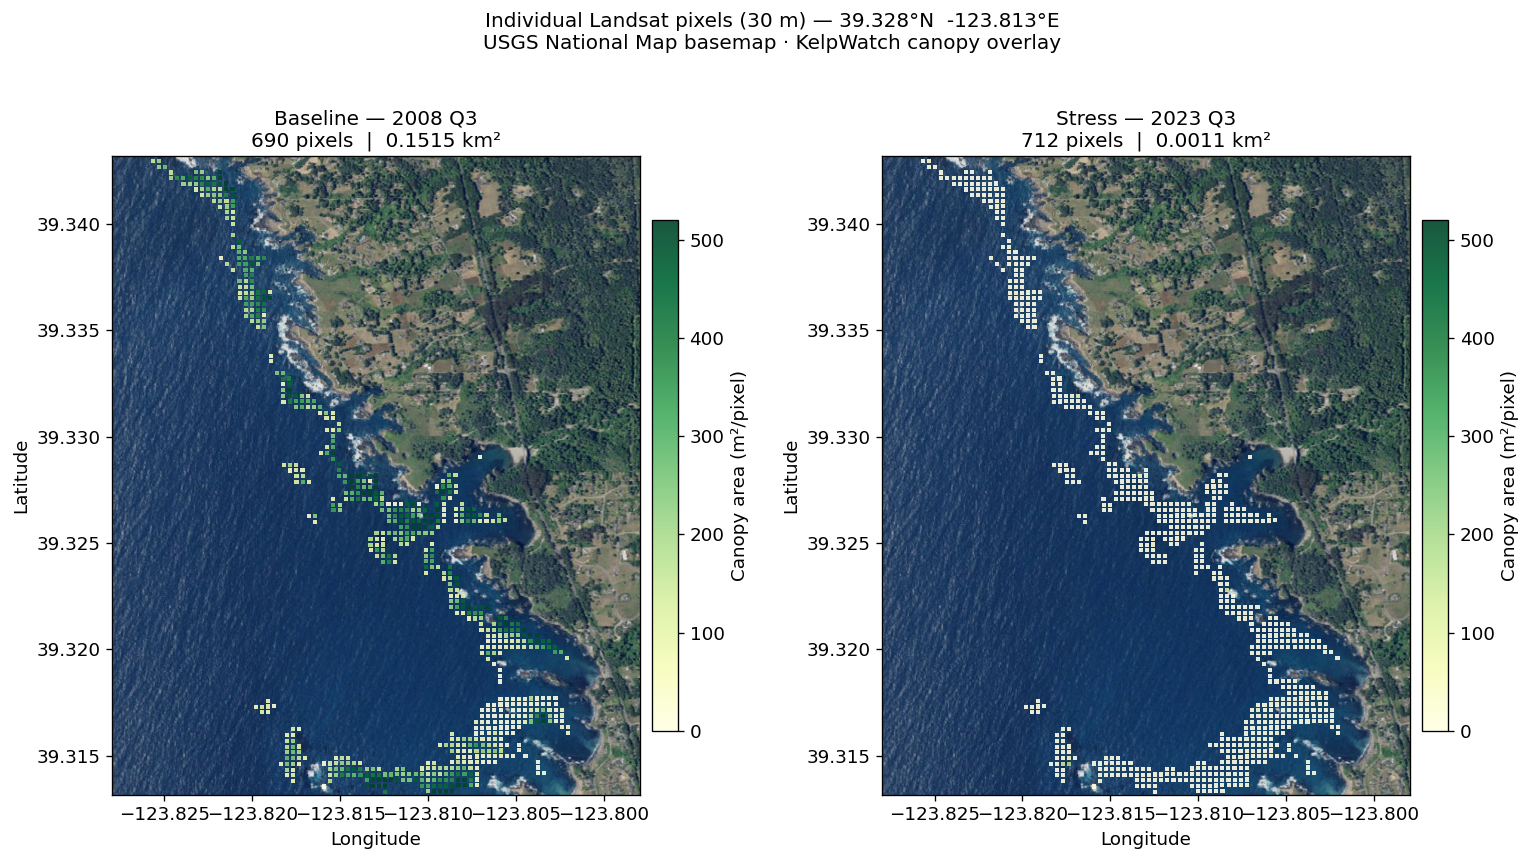

In [19]:
from PIL import Image
from io import BytesIO

# ── Pick years ────────────────────────────────────────────────────────────────
q3        = qs_a == 3
base_q3   = q3 & (yrs_a <= BASELINE_END_YR)
stress_q3   = q3 & (yrs_a > BASELINE_END_YR)

best_idx  = np.where(base_q3)[0][np.argmax(ext_km2[base_q3])]
worst_idx = np.where(stress_q3)[0][np.argmin(ext_km2[stress_q3])]
best_yr, worst_yr = int(yrs_a[best_idx]), int(yrs_a[worst_idx])
print(f'Baseline year: {best_yr} Q3  ({ext_km2[best_idx]:.2f} km²)')
print(f'Stress year:   {worst_yr} Q3  ({ext_km2[worst_idx]:.2f} km²)')

# ── Zoom: pick single highest-area pixel in baseline year as anchor ───────────
lat_px = ds['latitude'].values
lon_px = ds['longitude'].values
mendo_px = ((lat_px >= 38.5) & (lat_px <= 40.0) &
            (lon_px >= -124.5) & (lon_px <= -123.0))

area_base_full              = ds_a['area'].values[best_idx, :].astype(float)
area_base_full[ds_a['passes'].values[best_idx, :] == 0] = 0.0
mendo_idx                   = np.where(mendo_px)[0]
anchor                      = mendo_idx[area_base_full[mendo_idx].argmax()]
zoom_lat, zoom_lon          = float(lat_px[anchor]), float(lon_px[anchor])
print(f'Anchor pixel: {zoom_lat:.4f}°N  {zoom_lon:.4f}°E  '
      f'area={area_base_full[anchor]:.0f} m²')

# 0.015° half-width ≈ 1.7km — at 700×700px each Landsat pixel spans ~5 image pixels
DELTA = 0.015
bbox  = [zoom_lon - DELTA, zoom_lat - DELTA, zoom_lon + DELTA, zoom_lat + DELTA]

# ── Satellite basemap ─────────────────────────────────────────────────────────
WMS_URL = (
    'https://basemap.nationalmap.gov/arcgis/services/'
    'USGSImageryOnly/MapServer/WMSServer'
    '?SERVICE=WMS&VERSION=1.3.0&REQUEST=GetMap'
    '&FORMAT=image/jpeg&LAYERS=0&STYLES=&CRS=CRS:84'
    f'&BBOX={bbox[0]},{bbox[1]},{bbox[2]},{bbox[3]}'
    '&WIDTH=700&HEIGHT=700'
)
try:
    _r = requests.get(WMS_URL, timeout=20)
    _r.raise_for_status()
    satellite_img = Image.open(BytesIO(_r.content))
    print(f'Basemap: {satellite_img.size} px')
except Exception as _e:
    satellite_img = None
    print(f'[Basemap unavailable: {_e}]')

IMG_EXTENT = [bbox[0], bbox[2], bbox[1], bbox[3]]

# ── Kelp layers clipped to zoom bbox ─────────────────────────────────────────
zoom_px = (mendo_px &
           (lat_px >= bbox[1]) & (lat_px <= bbox[3]) &
           (lon_px >= bbox[0]) & (lon_px <= bbox[2]))

def zoom_layer(time_idx):
    a = ds_a['area'].values[time_idx, :].astype(float)
    p = ds_a['passes'].values[time_idx, :]
    a[p == 0] = np.nan
    return a[zoom_px], lat_px[zoom_px], lon_px[zoom_px]

area_b, lat_b, lon_b = zoom_layer(best_idx)
area_s, lat_s, lon_s = zoom_layer(worst_idx)

valid_b = area_b[~np.isnan(area_b)]
valid_s = area_s[~np.isnan(area_s)]
print(f'Pixels in bbox — baseline: {len(valid_b)}  stress: {len(valid_s)}')
vmax = np.percentile(np.concatenate([valid_b, valid_s]), 97) if len(valid_b) + len(valid_s) else 1

# Marker size in points² such that each ~30m pixel fills its footprint.
# At DELTA=0.015°, the axes span 0.03° ≈ ~2600m. Figure width ~7in.
# 1pt = 1/72 in. pts_per_deg = (7in/2 * 72pt/in) / 0.03deg ≈ 8400 pt/deg.
# 30m = 0.00027° → marker diameter ≈ 0.00027 * 8400 ≈ 2.3pt → s ≈ 5pt²
# Use s=6 so pixels are just touching; increase if they look small.
MARKER_S = 6

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 7))

for ax, (yr, area_v, lat_v, lon_v, label) in zip(axes, [
    (best_yr,  area_b, lat_b, lon_b, 'Baseline'),
    (worst_yr, area_s, lat_s, lon_s, 'Stress'),
]):
    if satellite_img is not None:
        ax.imshow(satellite_img, extent=IMG_EXTENT, aspect='auto', origin='upper')
    else:
        ax.set_facecolor('#1a3a5c')

    observed = ~np.isnan(area_v)
    if observed.any():
        sc = ax.scatter(lon_v[observed], lat_v[observed],
                        c=area_v[observed], cmap='YlGn', alpha=0.9,
                        vmin=0, vmax=vmax, s=MARKER_S,
                        marker='s', linewidths=0, zorder=2)
        plt.colorbar(sc, ax=ax, label='Canopy area (m²/pixel)', shrink=0.8, pad=0.02)

    total_k2 = np.nansum(area_v[observed]) / 1e6 if observed.any() else 0.0
    ax.set_xlim(bbox[0], bbox[2])
    ax.set_ylim(bbox[1], bbox[3])
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'{label} — {yr} Q3\n'
                 f'{observed.sum()} pixels  |  {total_k2:.4f} km²',
                 fontsize=12)

plt.suptitle(f'Individual Landsat pixels (30 m) — {zoom_lat:.3f}°N  {zoom_lon:.3f}°E\n'
             'USGS National Map basemap · KelpWatch canopy overlay',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()